In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
metrics = pd.read_csv('1.0.3/metrics.csv')
metrics.head()

,epoch,step,train_loss_epoch,train_loss_step,training/lr_epoch,training/lr_step,val_loss
0,0,0,NaN,8.361532,NaN,0.000004,NaN
1,0,1,NaN,6.802515,NaN,0.000004,NaN
2,0,2,NaN,5.473734,NaN,0.000004,NaN
3,0,3,NaN,3.654572,NaN,0.000004,NaN
4,0,4,NaN,5.078099,NaN,0.000004,NaN


In [3]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import plotly.express as px

metrics = pd.read_csv('1.0.3/metrics.csv')
metrics.head()

fig = px.line(metrics, x='step', y=['train_loss_step', 'val_loss'], title='Loss over time')
fig.show()

In [4]:
after_converge = metrics[metrics['step'] > 67700]
after_converge

,epoch,step,train_loss_epoch,train_loss_step,training/lr_epoch,training/lr_step,val_loss
68378,1,67701,NaN,0.993492,NaN,0.0001,NaN
68379,1,67702,NaN,0.949775,NaN,0.0001,NaN
68380,1,67703,NaN,1.187801,NaN,0.0001,NaN
68381,1,67704,NaN,1.763360,NaN,0.0001,NaN
68382,1,67705,NaN,1.705682,NaN,0.0001,NaN
...,...,...,...,...,...,...,...
89652,2,88764,NaN,1.698646,NaN,0.0001,NaN
89653,2,88765,NaN,1.820898,NaN,0.0001,NaN
89654,2,88766,NaN,1.573935,NaN,0.0001,NaN
89655,2,88767,NaN,1.631954,NaN,0.0001,NaN


In [5]:
# Find difference larger than 0.5 loss between two steps
diff = after_converge['train_loss_step'].diff()
idx = after_converge[diff < -0.5]
diff = diff[diff < -0.5]
diff
# metrics.loc[[idx-1, idx]]

68774   -0.543659
68913   -0.517089
72555   -0.558887
73164   -0.549234
74280   -0.557222
75359   -0.551636
75457   -0.520288
77253   -1.561356
77259   -2.659210
77271   -0.732477
81353   -0.547202
87062   -0.511906
87203   -0.535063
Name: train_loss_step, dtype: float64

In [6]:
import torch

# Load the problematic batch data
batch_data_path = '1.0.3/abnormal_event_records/batch_67703_25959_20250728_011456.pt'
# Use map_location to avoid GPU errors if the notebook is run on a different machine
batch_data = torch.load(batch_data_path, map_location=torch.device('cpu'))

# Inspect the data
print(f"Loaded data type: {type(batch_data)}\n")

if isinstance(batch_data, dict):
    print("Batch data contains the following keys:")
    for key, value in batch_data.items():
        print(f"\n--- Key: '{key}' ---")
        print(f"  Type: {type(value)}")
        if hasattr(value, 'shape'):
            print(f"  Shape: {value.shape}")
        if hasattr(value, 'dtype'):
            print(f"  Dtype: {value.dtype}")
        
        # Avoid printing huge tensors to the console
        if torch.is_tensor(value) and value.numel() > 100:
            print("  Value: (Tensor too large to display)")
        else:
            print(f"  Value: {value}")
else:
    print("Data is not a dictionary.")
    if hasattr(batch_data, 'shape'):
        print(f"Shape: {batch_data.shape}")
    if hasattr(batch_data, 'dtype'):
        print(f"Dtype: {batch_data.dtype}")
    # Avoid printing huge tensors
    if torch.is_tensor(batch_data) and batch_data.numel() > 100:
        print("Value: (Tensor too large to display)")
    else:
        print(f"Value: {batch_data}")

Loaded data type: <class 'dict'>

Batch data contains the following keys:

--- Key: 'mel_data' ---
  Type: <class 'torch.Tensor'>
  Shape: torch.Size([8, 384, 12])
  Dtype: torch.uint8
  Value: (Tensor too large to display)

--- Key: 'acc_data' ---
  Type: <class 'torch.Tensor'>
  Shape: torch.Size([8, 384, 12])
  Dtype: torch.uint8
  Value: (Tensor too large to display)

--- Key: 'pitch_shift' ---
  Type: <class 'torch.Tensor'>
  Shape: torch.Size([8])
  Dtype: torch.int64
  Value: tensor([-2,  5,  5,  6,  3,  0, -2,  0])


--- Inspecting Sample Index: 0 ---
Pitch Shift Applied: -2 semitones


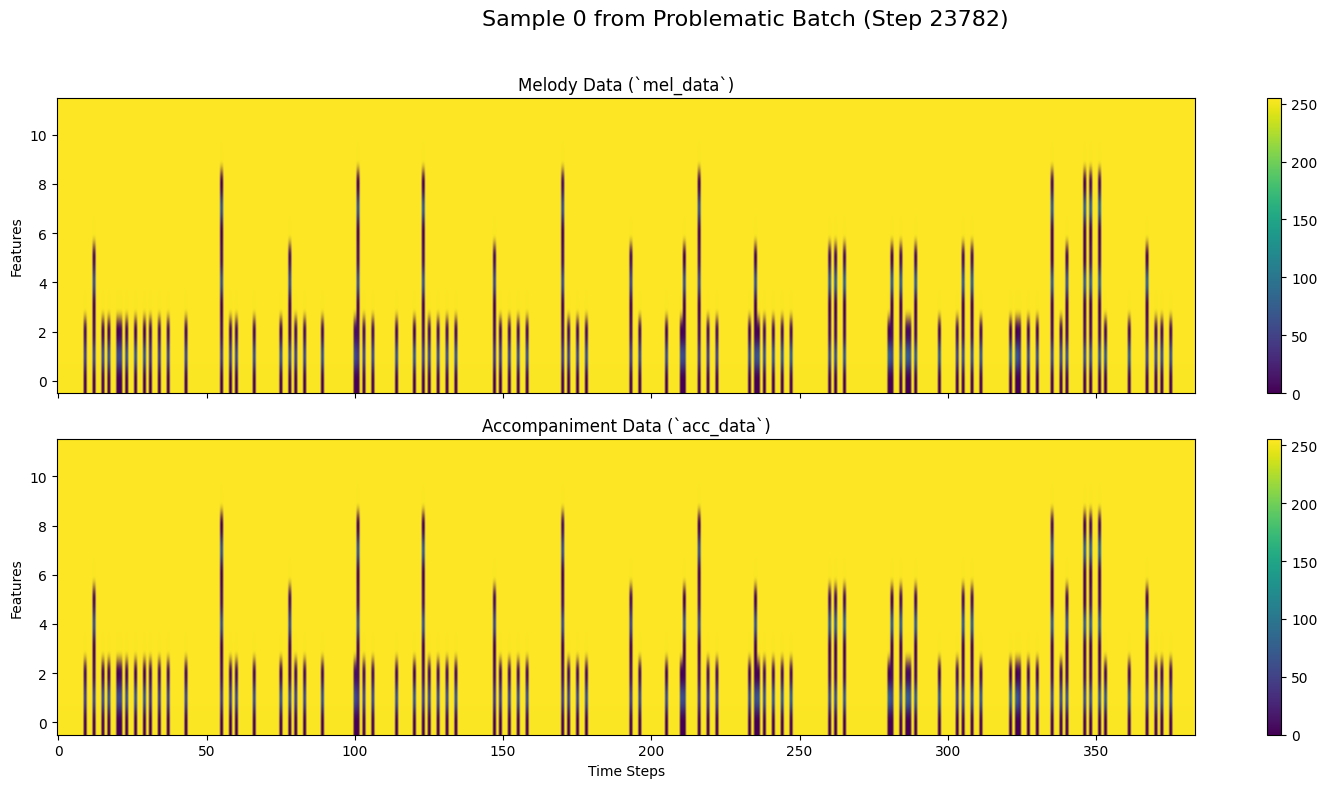

In [7]:
import matplotlib.pyplot as plt

# --- Select a sample from the batch to inspect ---
sample_index = 0
# ------------------------------------------------

melody_sample = batch_data['mel_data'][sample_index]
accompaniment_sample = batch_data['acc_data'][sample_index]
pitch_shift_amount = batch_data['pitch_shift'][sample_index]

print(f"--- Inspecting Sample Index: {sample_index} ---")
print(f"Pitch Shift Applied: {pitch_shift_amount.item()} semitones")

# Create plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.suptitle(f'Sample {sample_index} from Problematic Batch (Step 23782)', fontsize=16)

# Plot Melody
# We use .T to have time on the x-axis and features on the y-axis
im1 = ax1.imshow(melody_sample.T.float(), aspect='auto', origin='lower', cmap='viridis')
ax1.set_title('Melody Data (`mel_data`)')
ax1.set_ylabel('Features')
fig.colorbar(im1, ax=ax1)

# Plot Accompaniment
im2 = ax2.imshow(accompaniment_sample.T.float(), aspect='auto', origin='lower', cmap='viridis')
ax2.set_title('Accompaniment Data (`acc_data`)')
ax2.set_xlabel('Time Steps')
ax2.set_ylabel('Features')
fig.colorbar(im2, ax=ax2)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


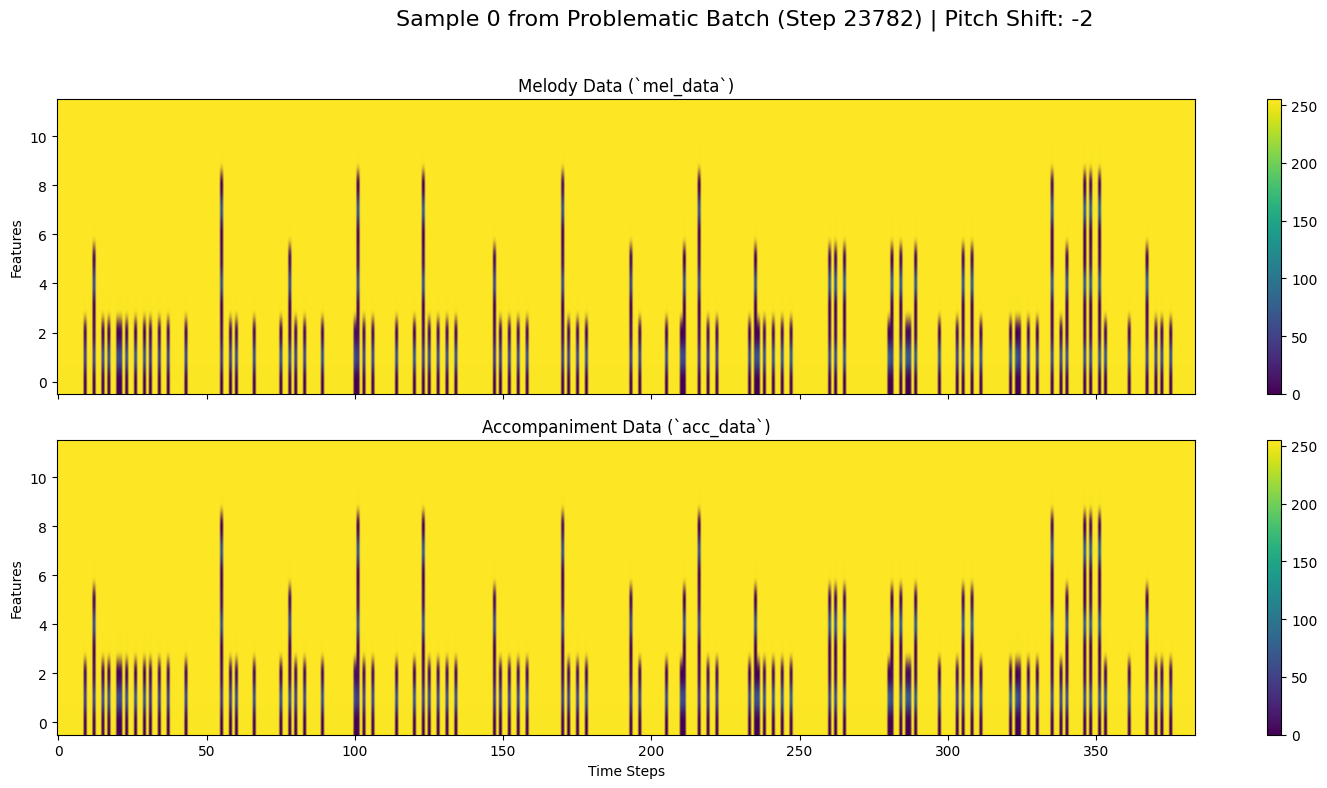

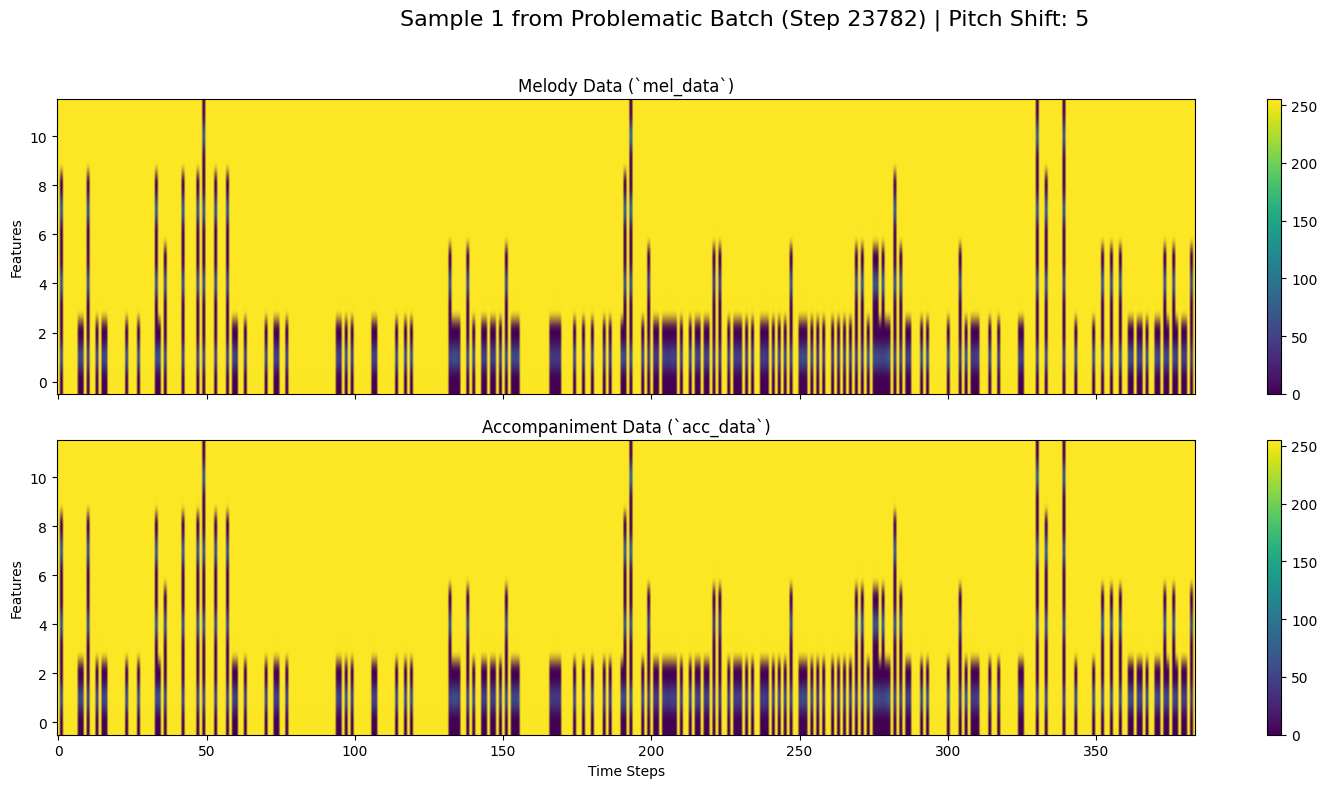

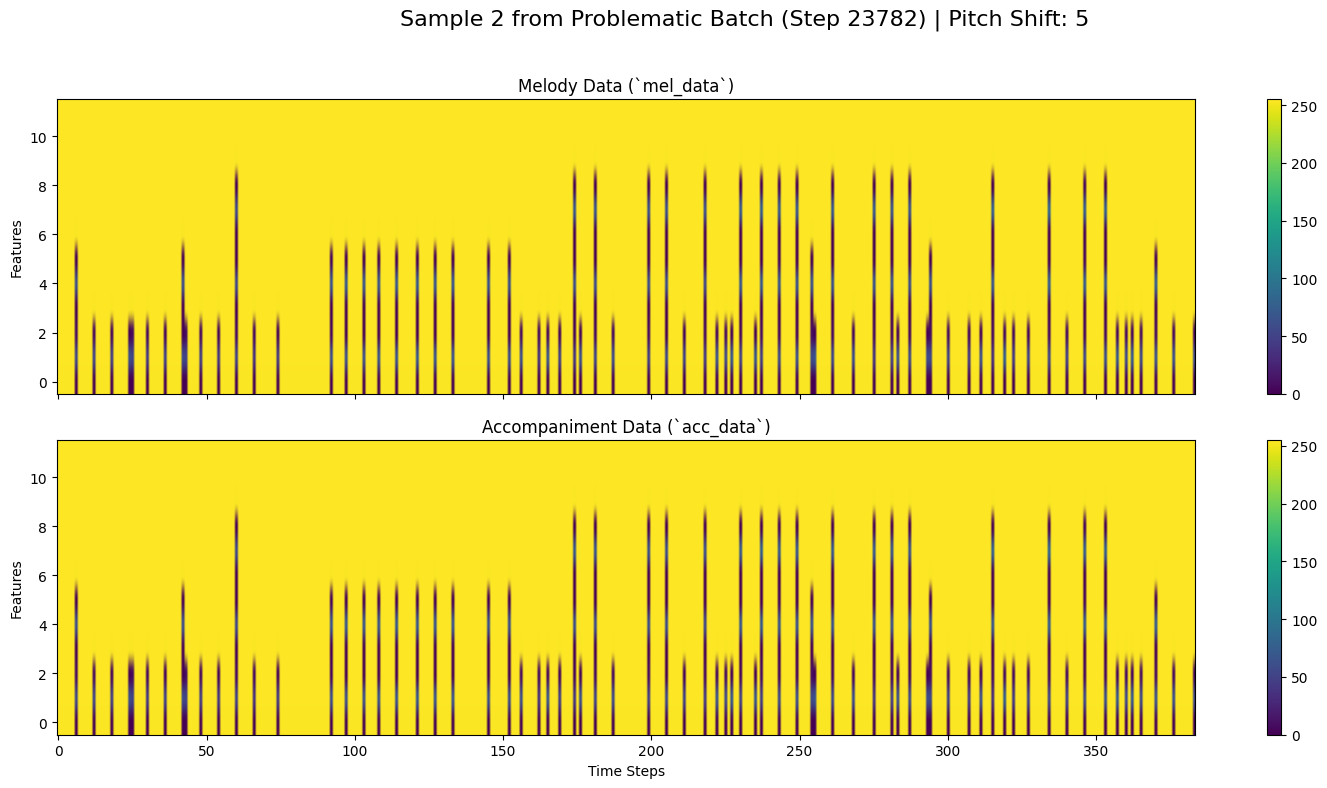

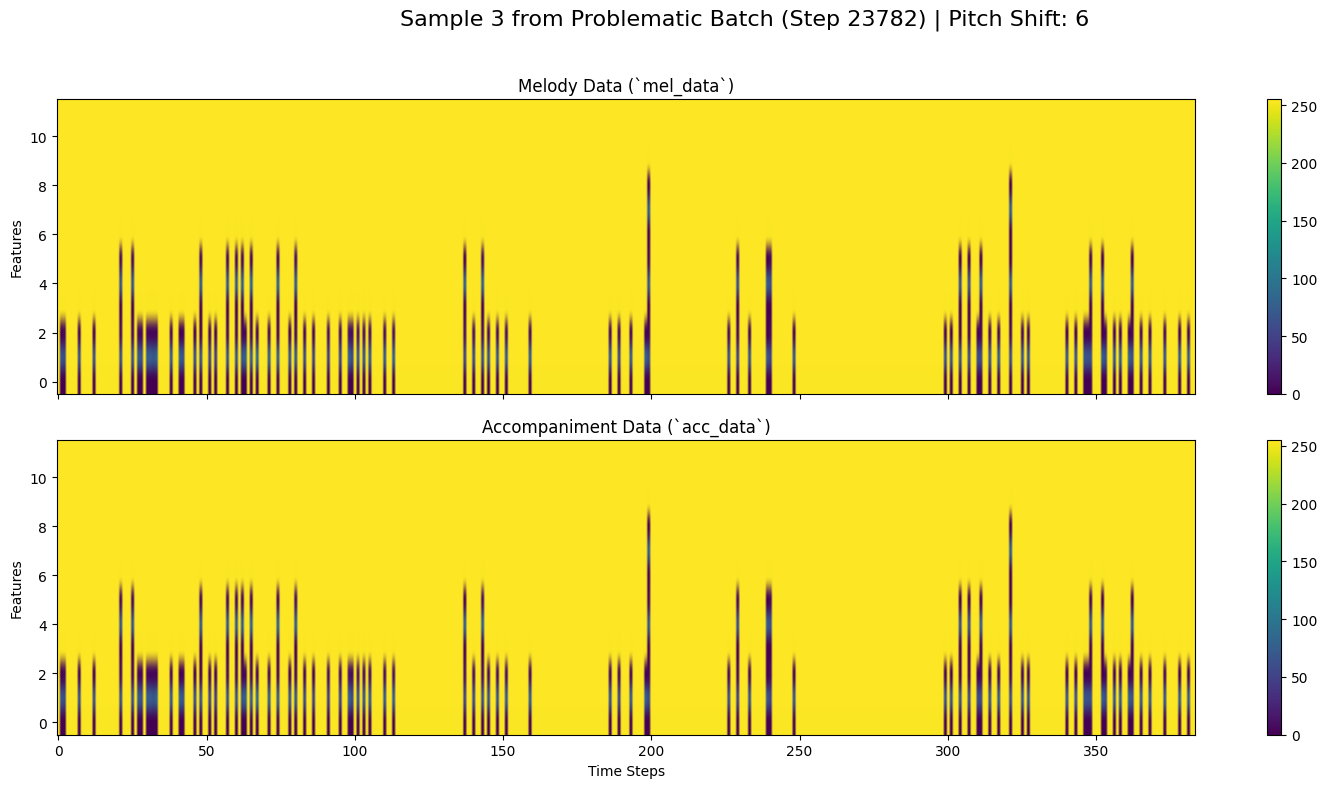

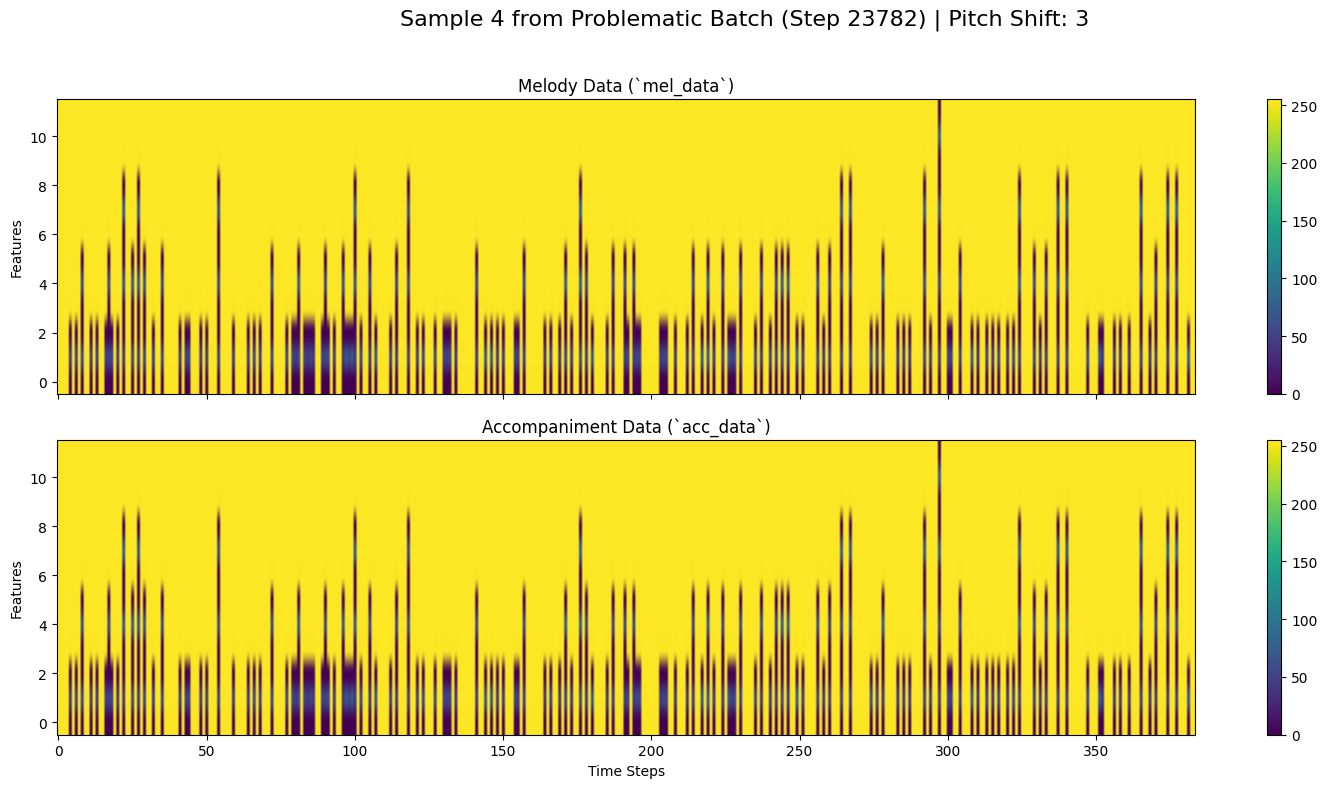

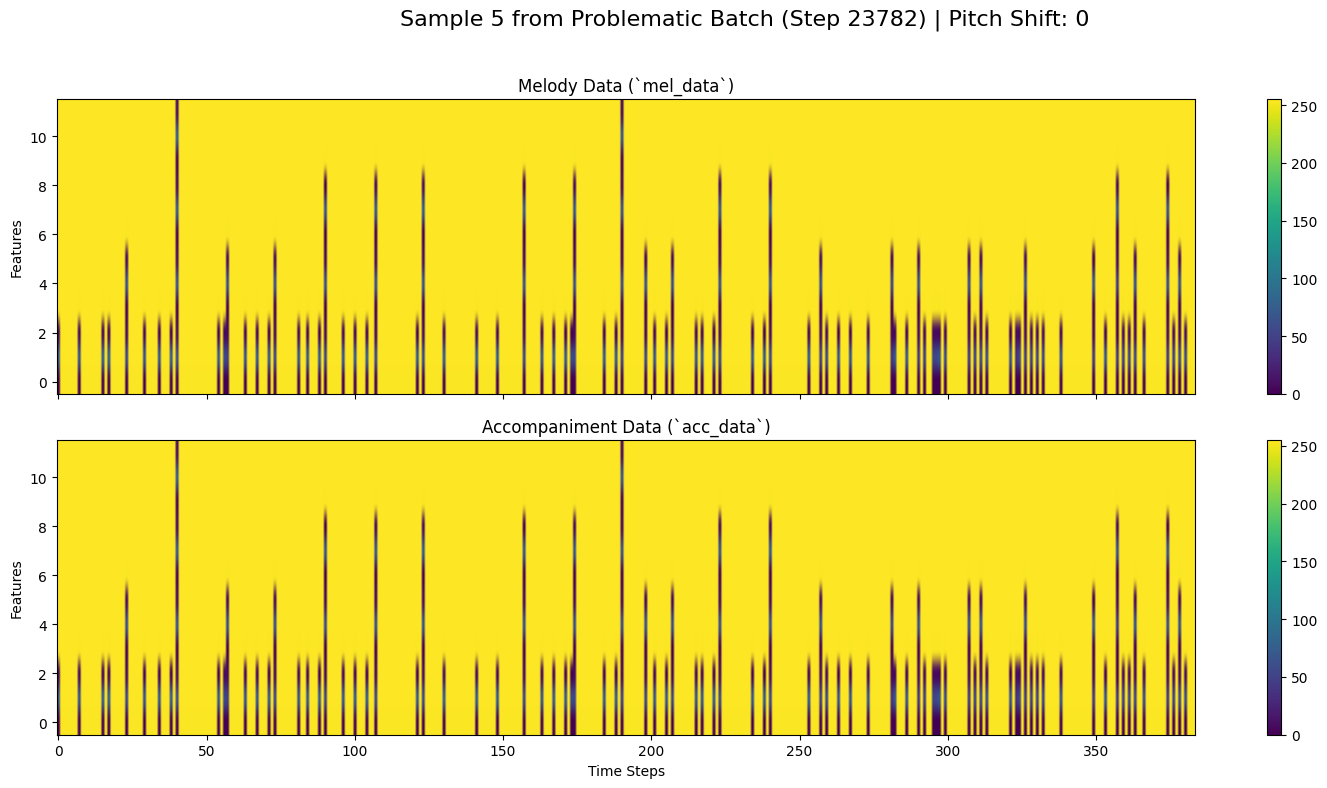

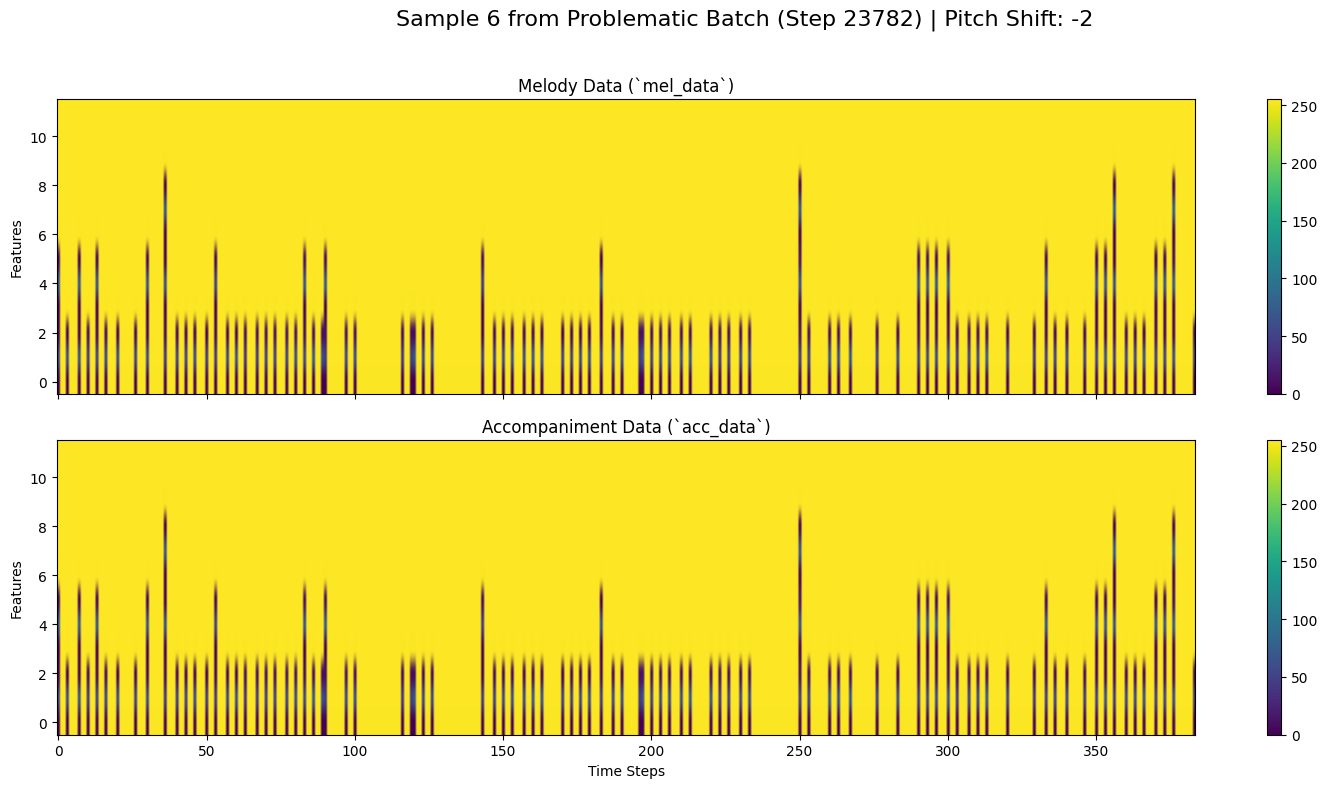

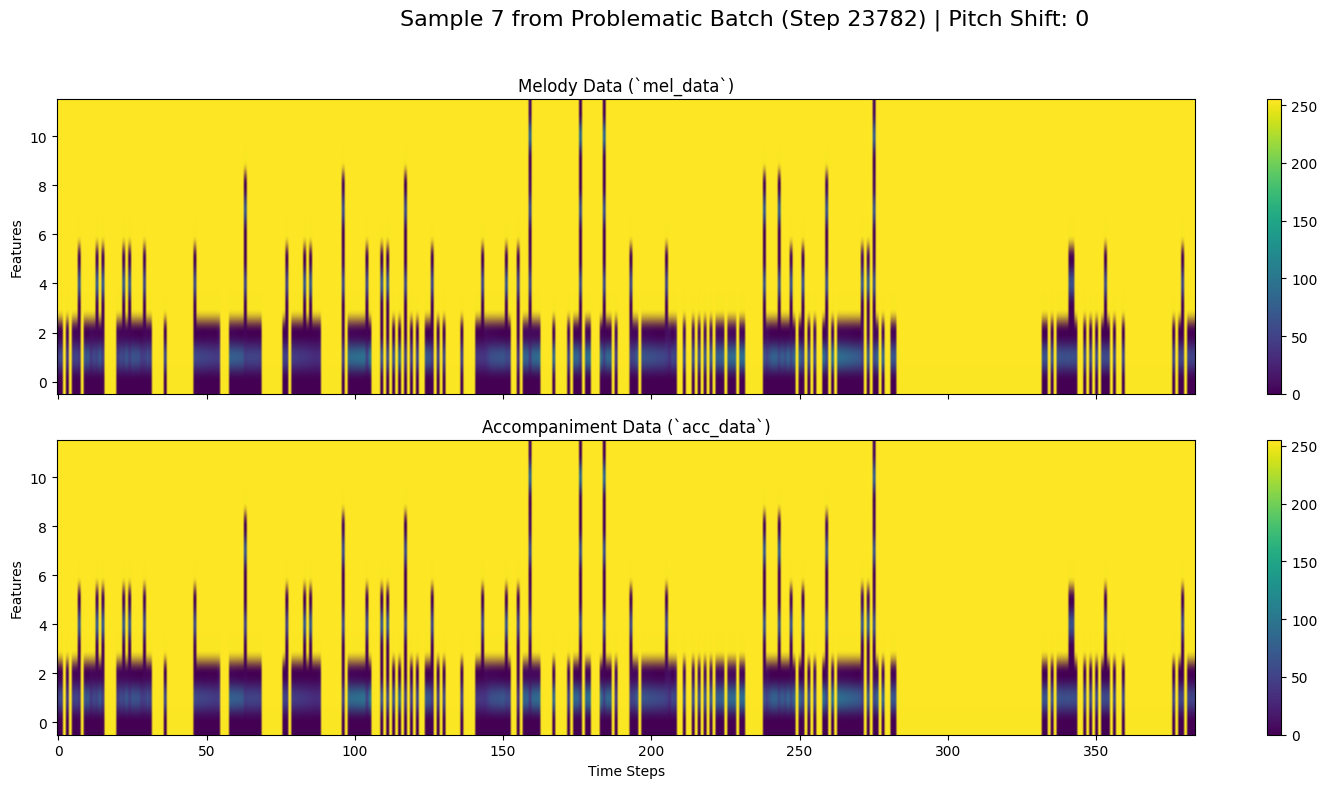

In [8]:
import matplotlib.pyplot as plt

# Loop through all samples in the batch and plot them
for sample_index in range(len(batch_data['mel_data'])):
    melody_sample = batch_data['mel_data'][sample_index]
    accompaniment_sample = batch_data['acc_data'][sample_index]
    pitch_shift_amount = batch_data['pitch_shift'][sample_index].item()
    
    # Create plots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    fig.suptitle(f'Sample {sample_index} from Problematic Batch (Step 23782) | Pitch Shift: {pitch_shift_amount}', fontsize=16)

    # Plot Melody
    im1 = ax1.imshow(melody_sample.T.float(), aspect='auto', origin='lower', cmap='viridis')
    ax1.set_title('Melody Data (`mel_data`)')
    ax1.set_ylabel('Features')
    fig.colorbar(im1, ax=ax1)

    # Plot Accompaniment
    im2 = ax2.imshow(accompaniment_sample.T.float(), aspect='auto', origin='lower', cmap='viridis')
    ax2.set_title('Accompaniment Data (`acc_data`)')
    ax2.set_xlabel('Time Steps')
    ax2.set_ylabel('Features')
    fig.colorbar(im2, ax=ax2)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

--- Generating Detailed Piano Roll Visualizations for Each Sample ---


/tmp/ipykernel_2114881/3328679878.py:123: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



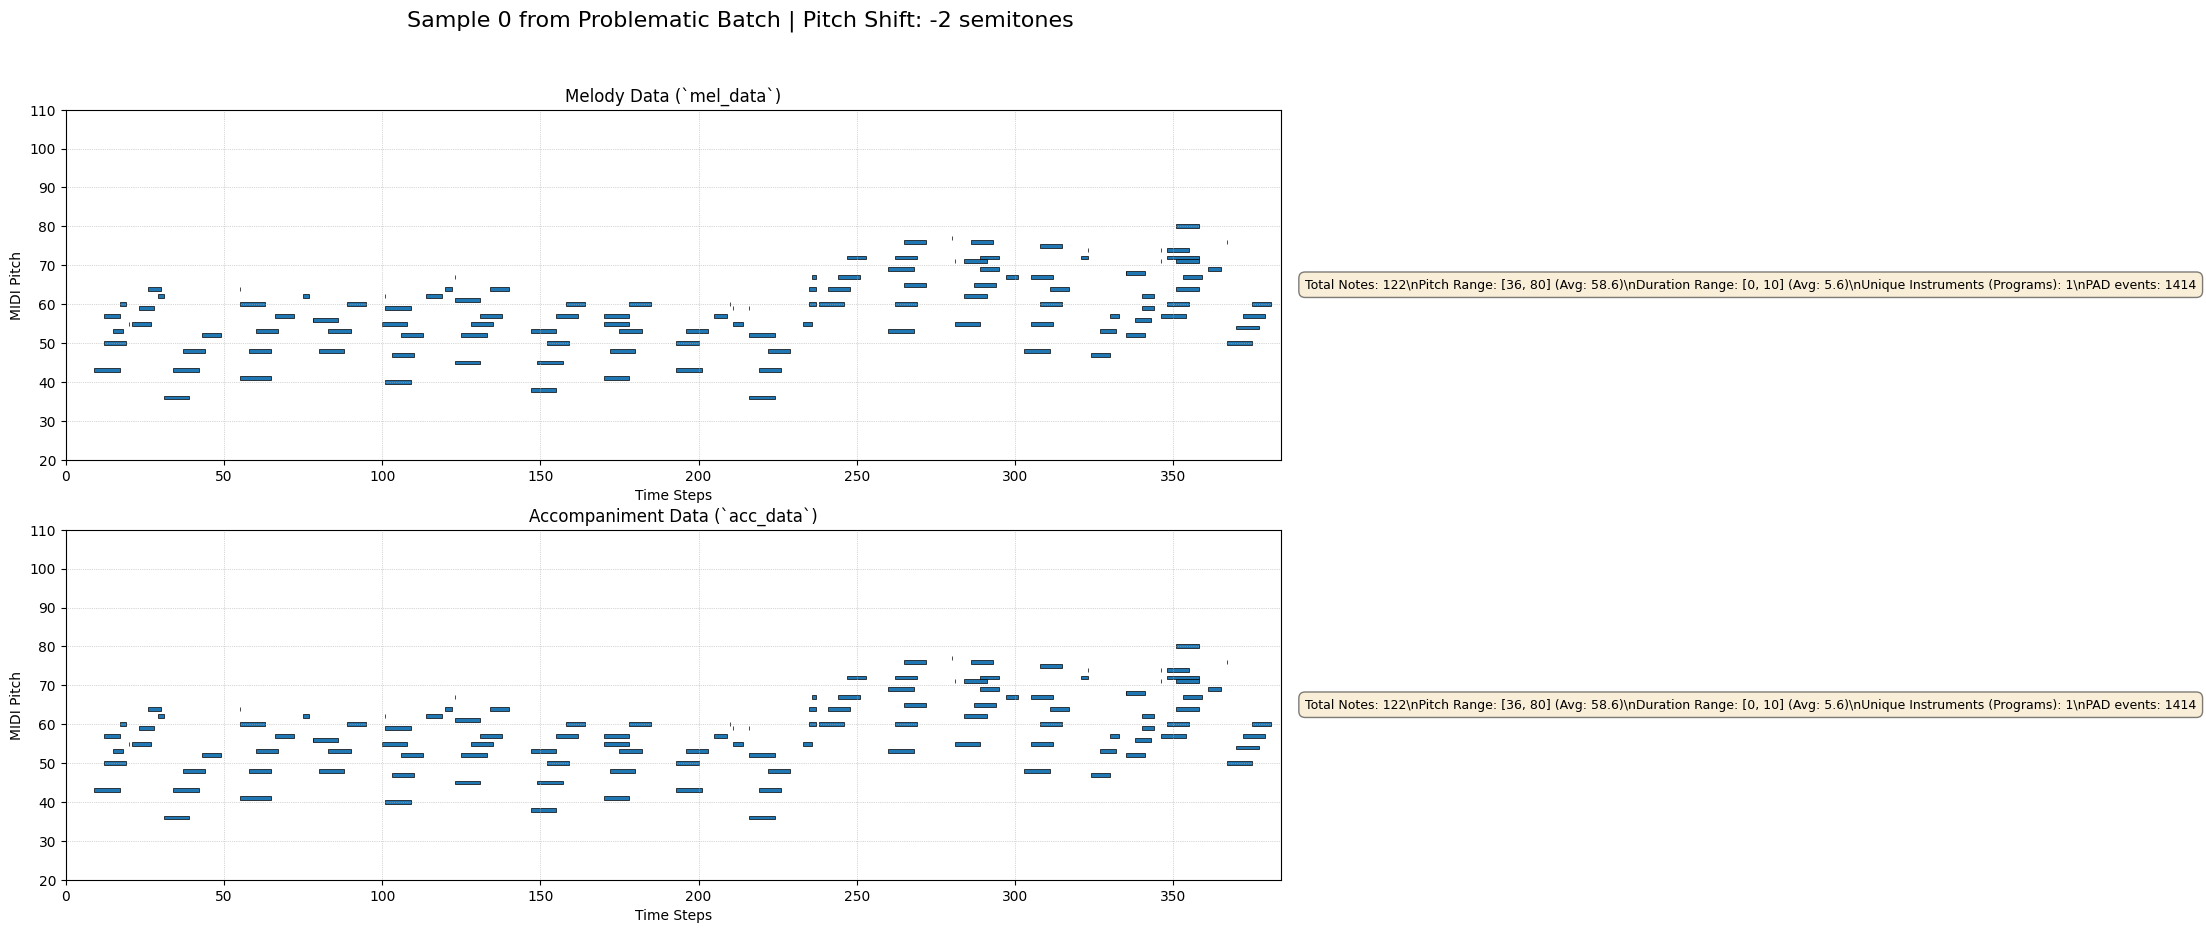

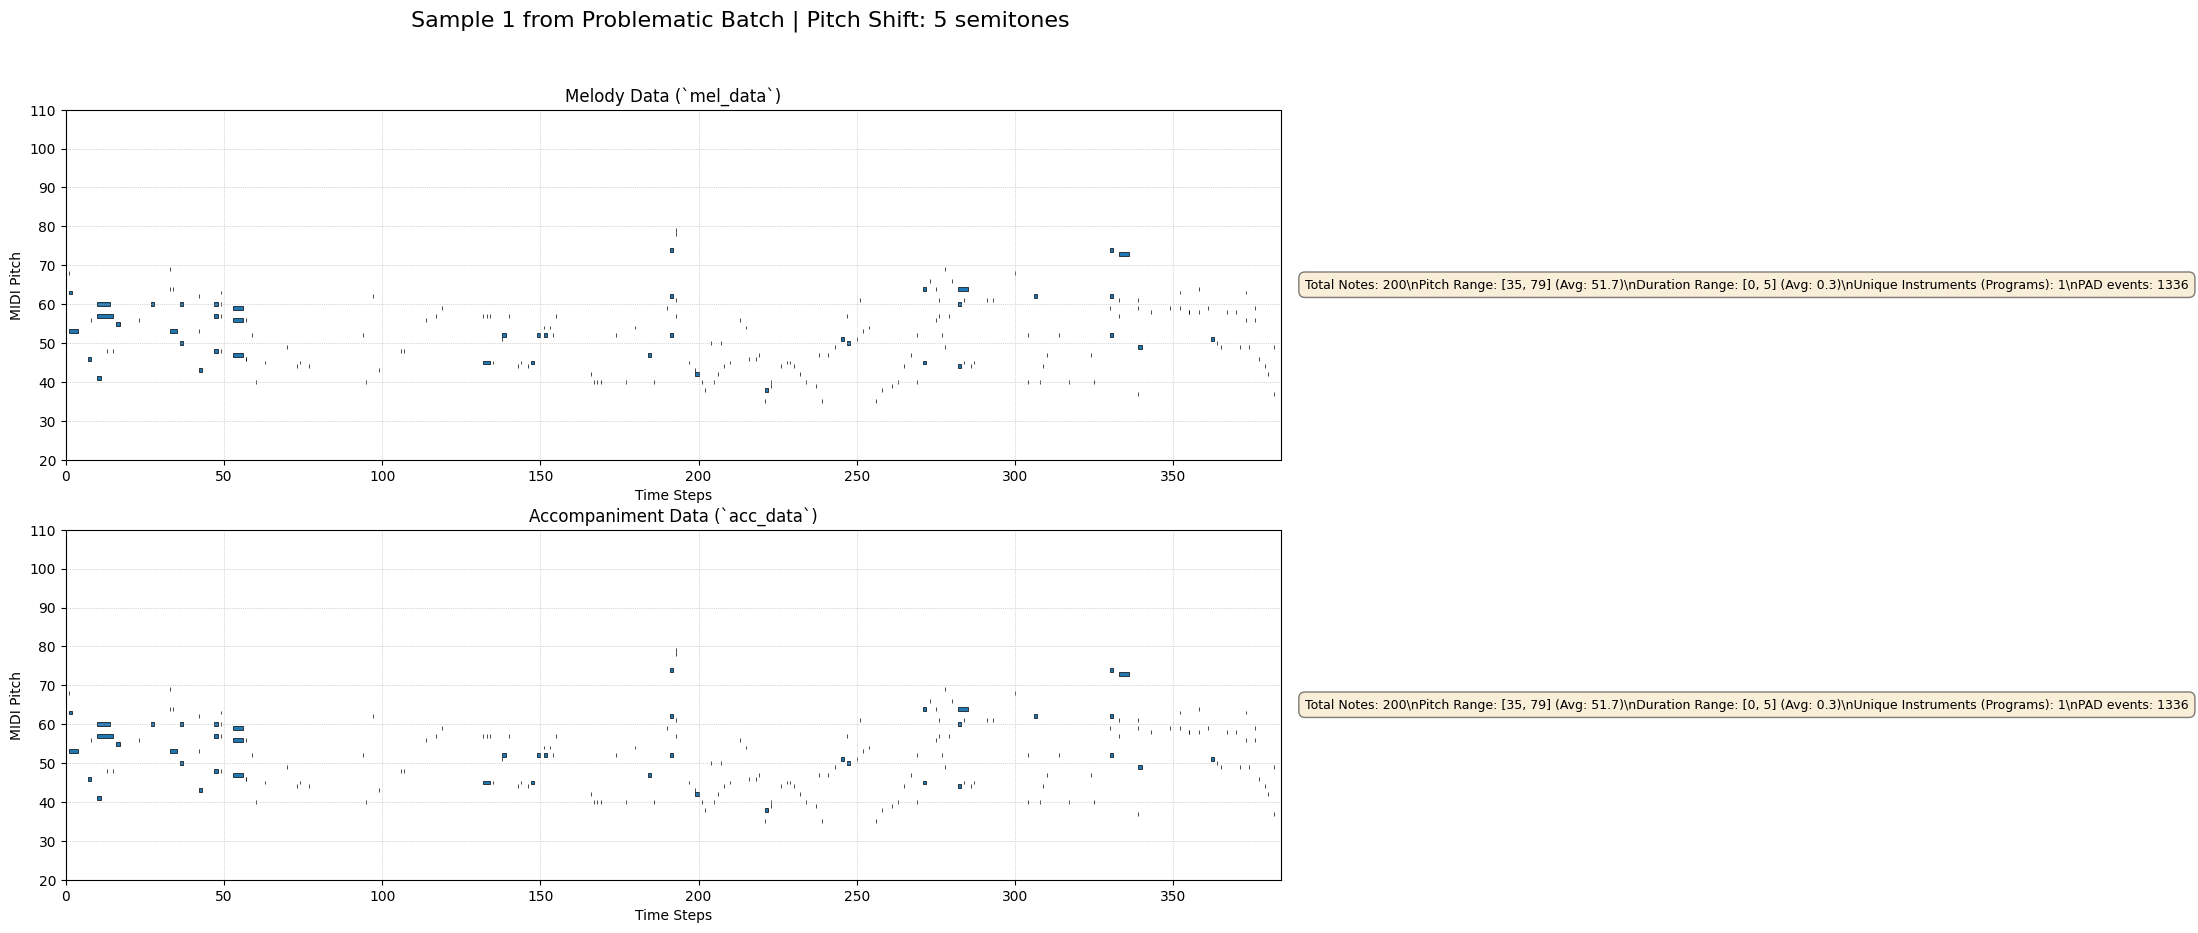

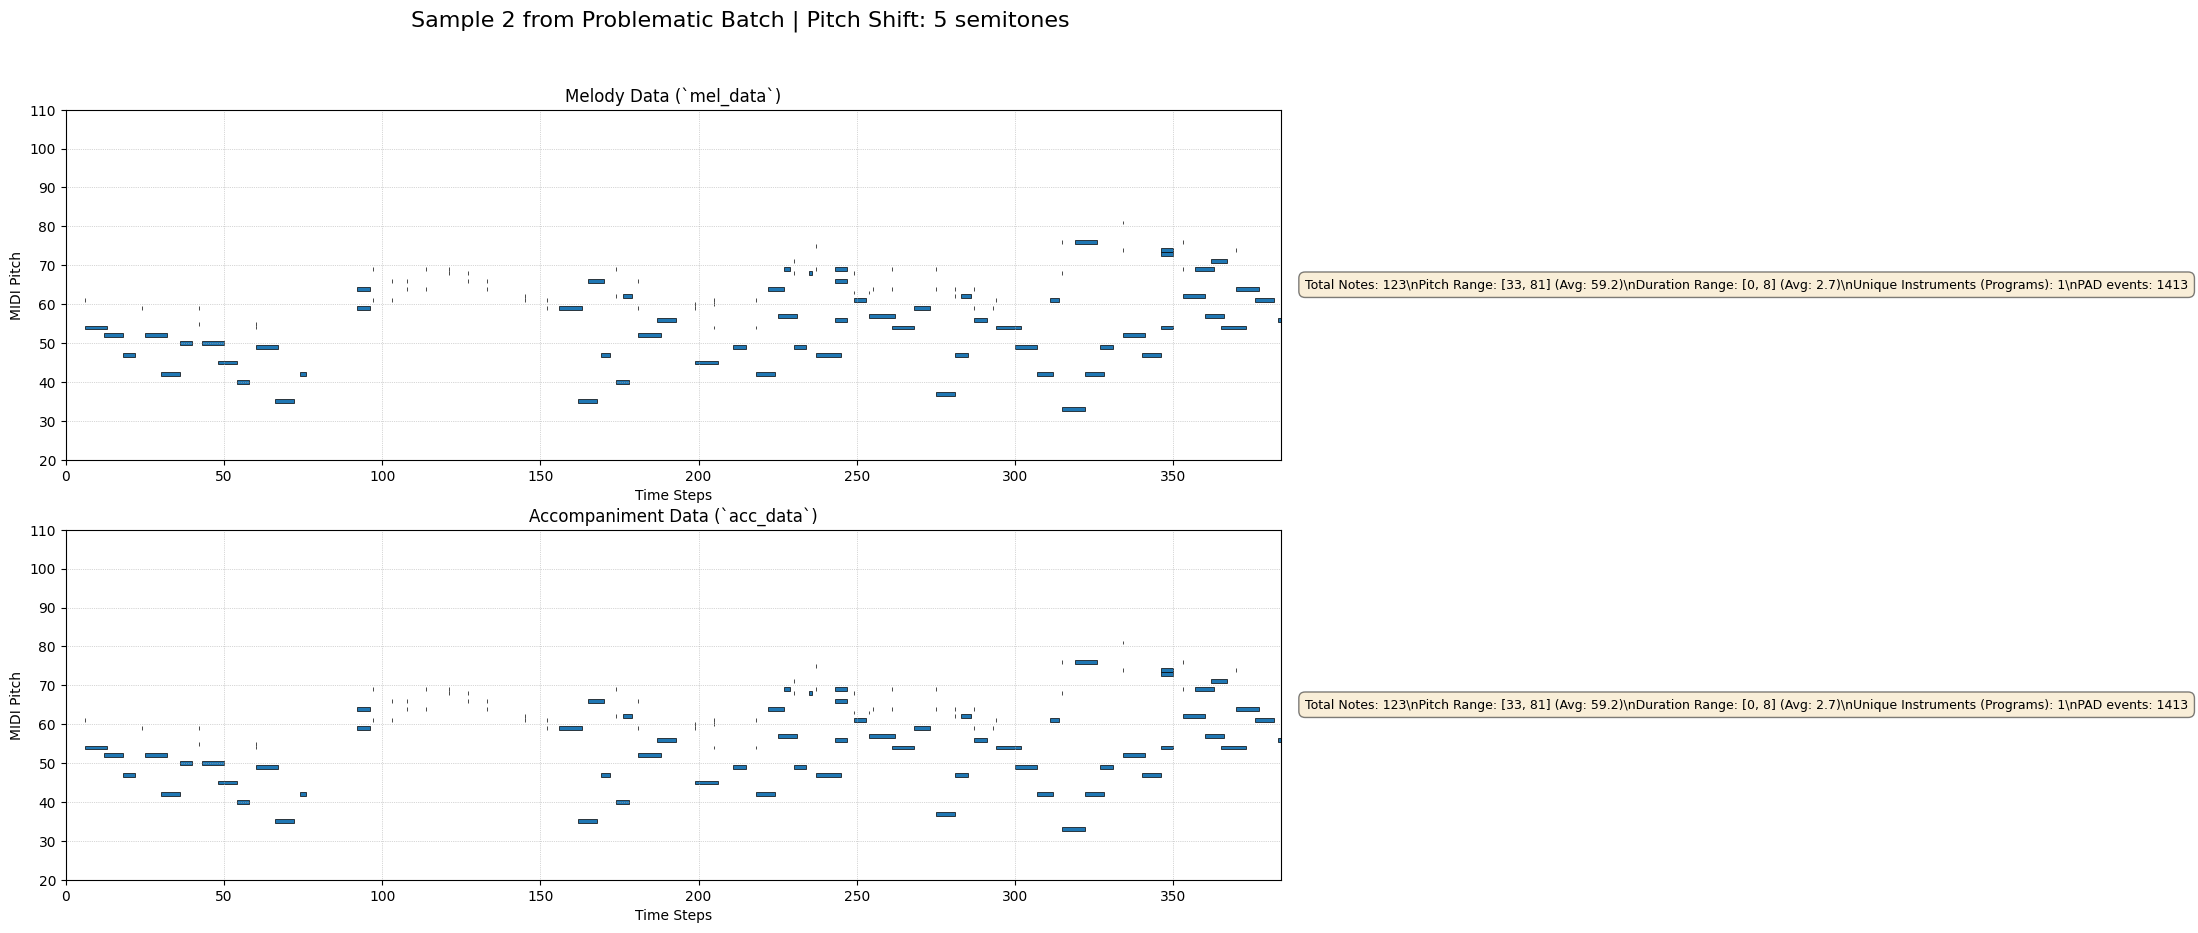

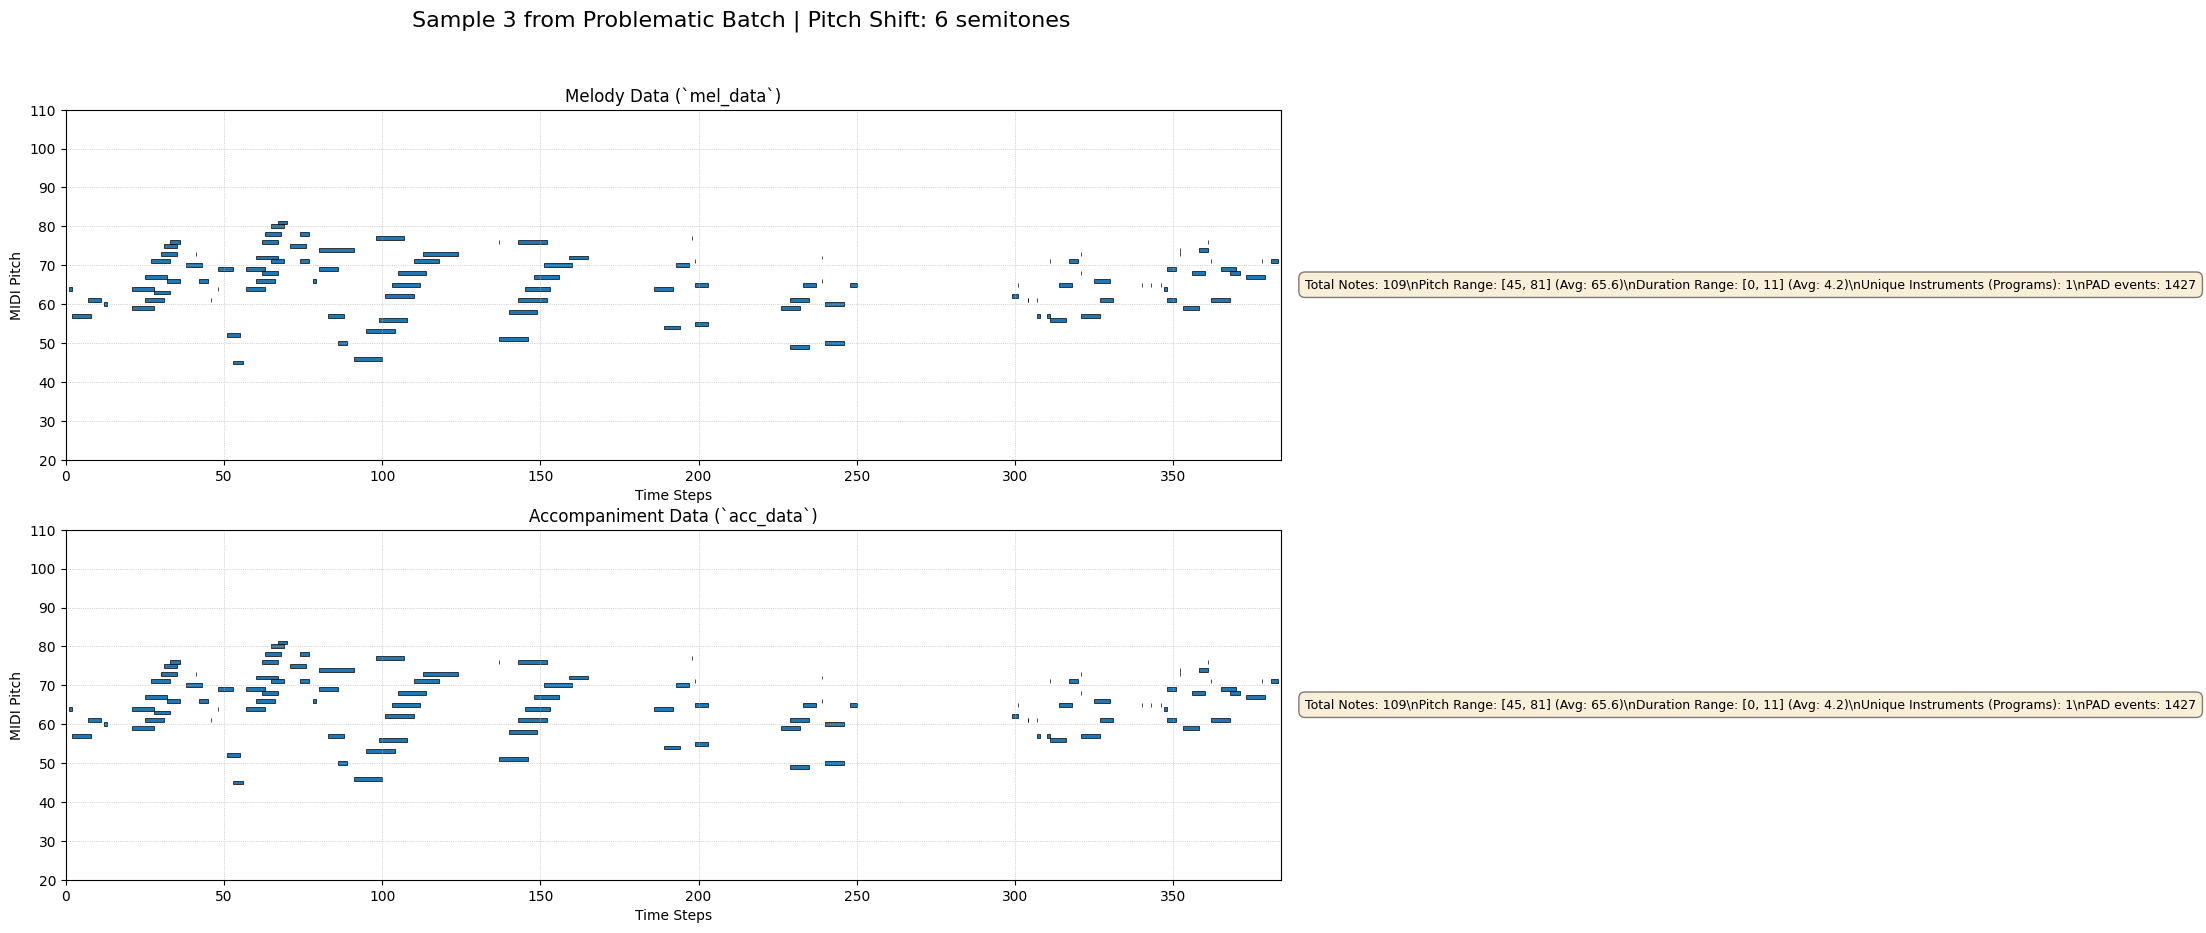

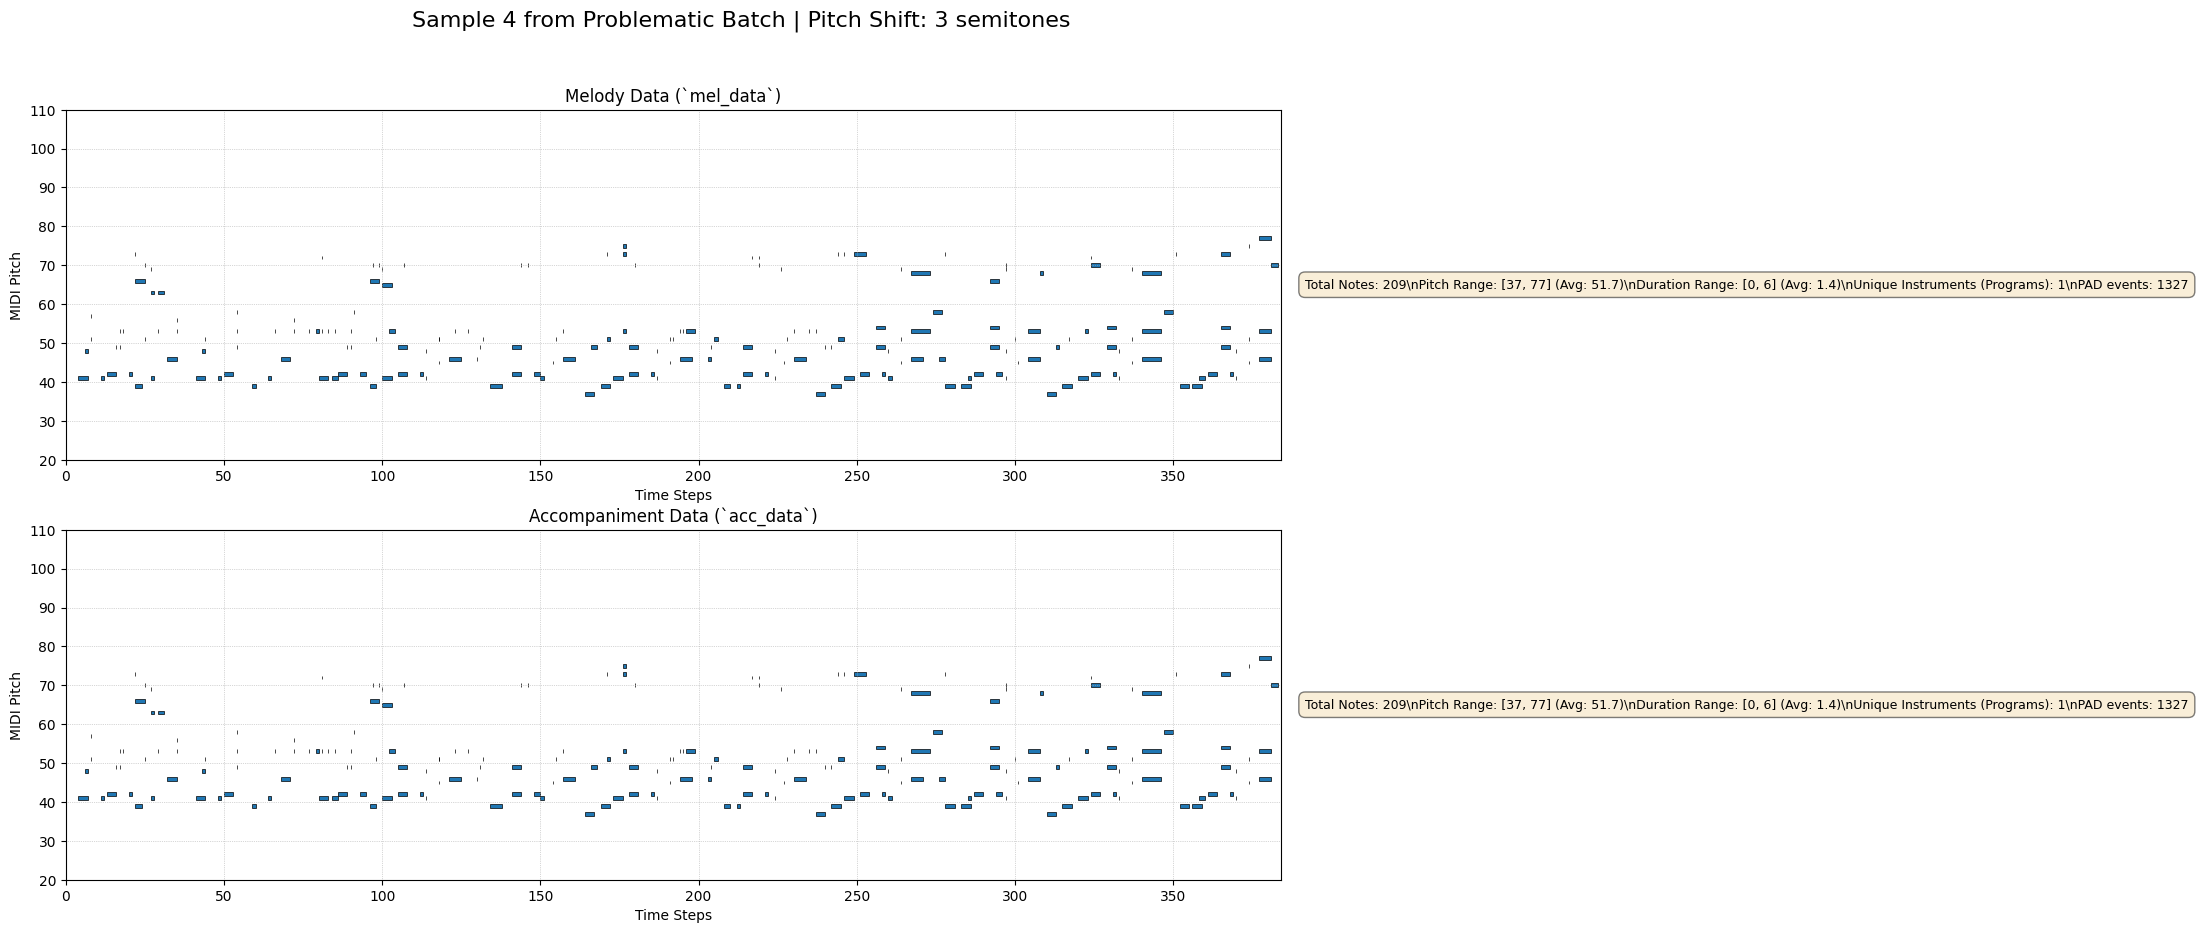

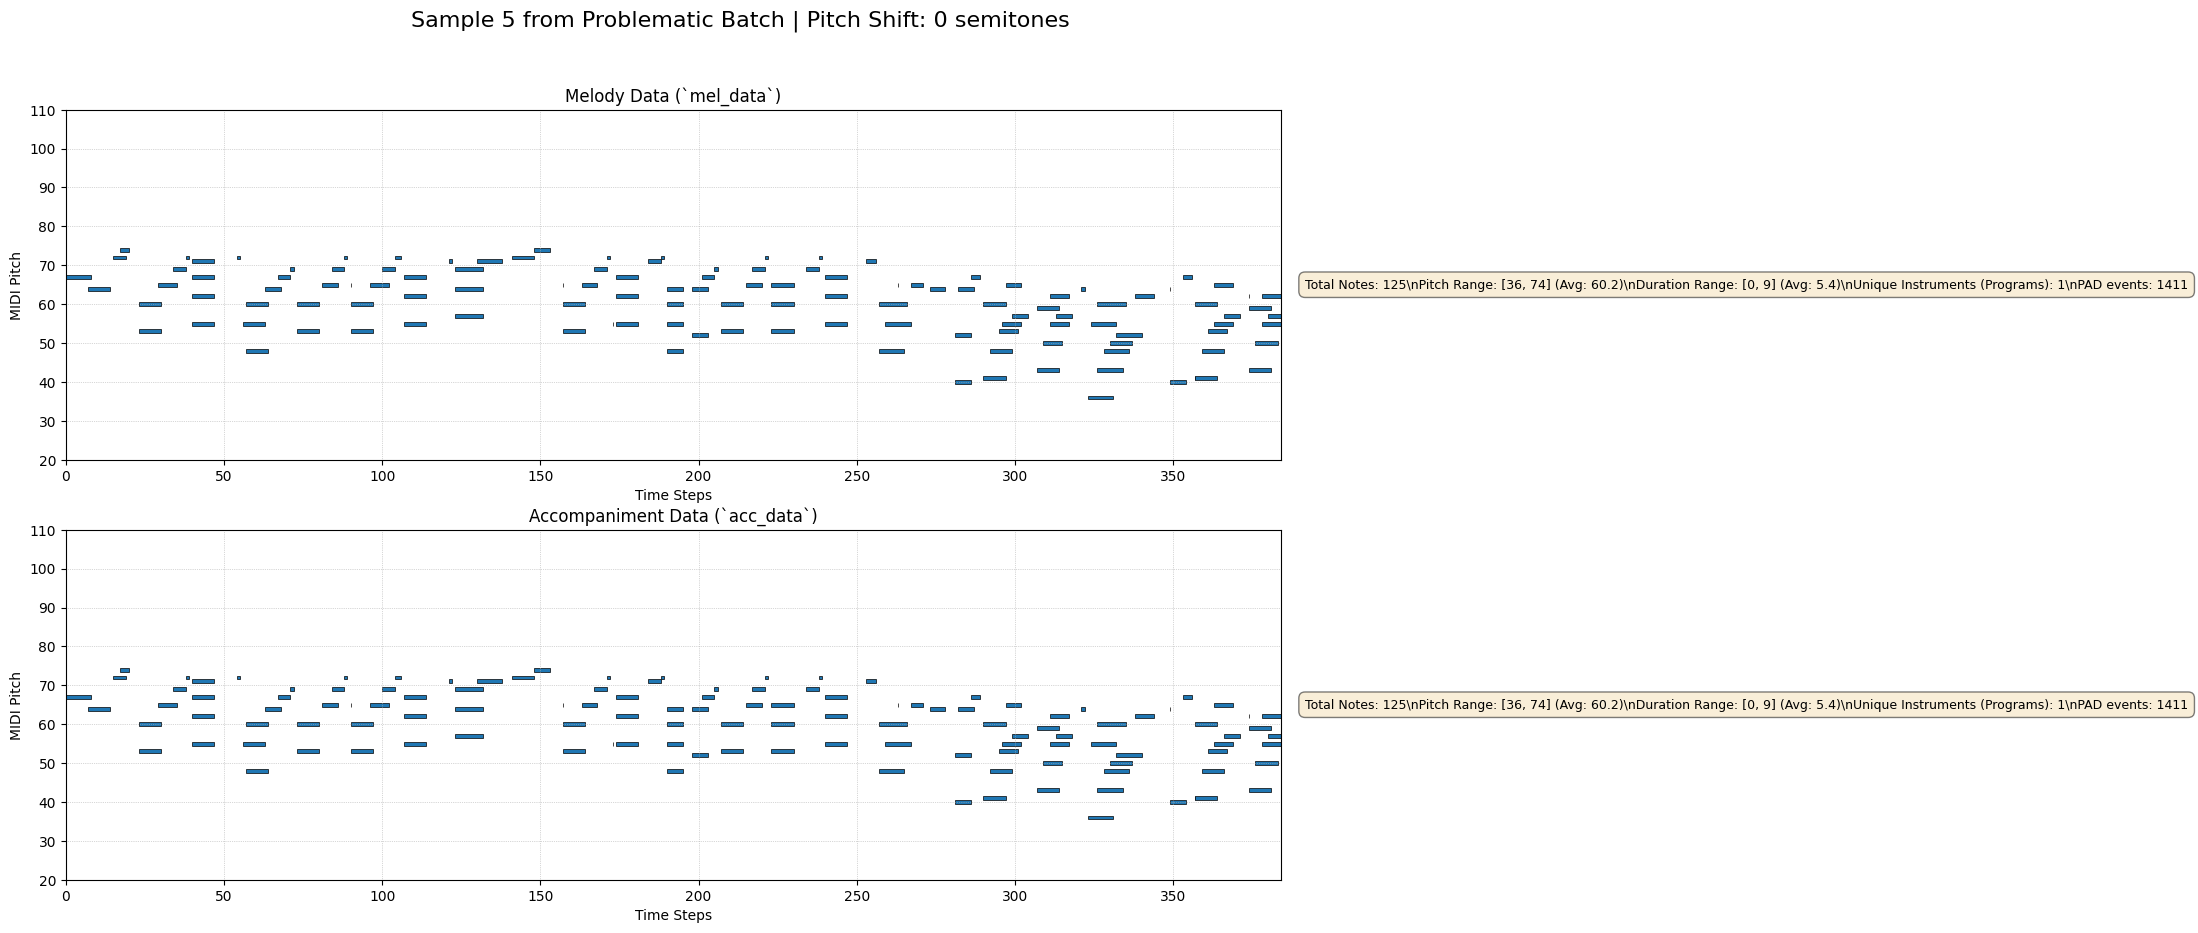

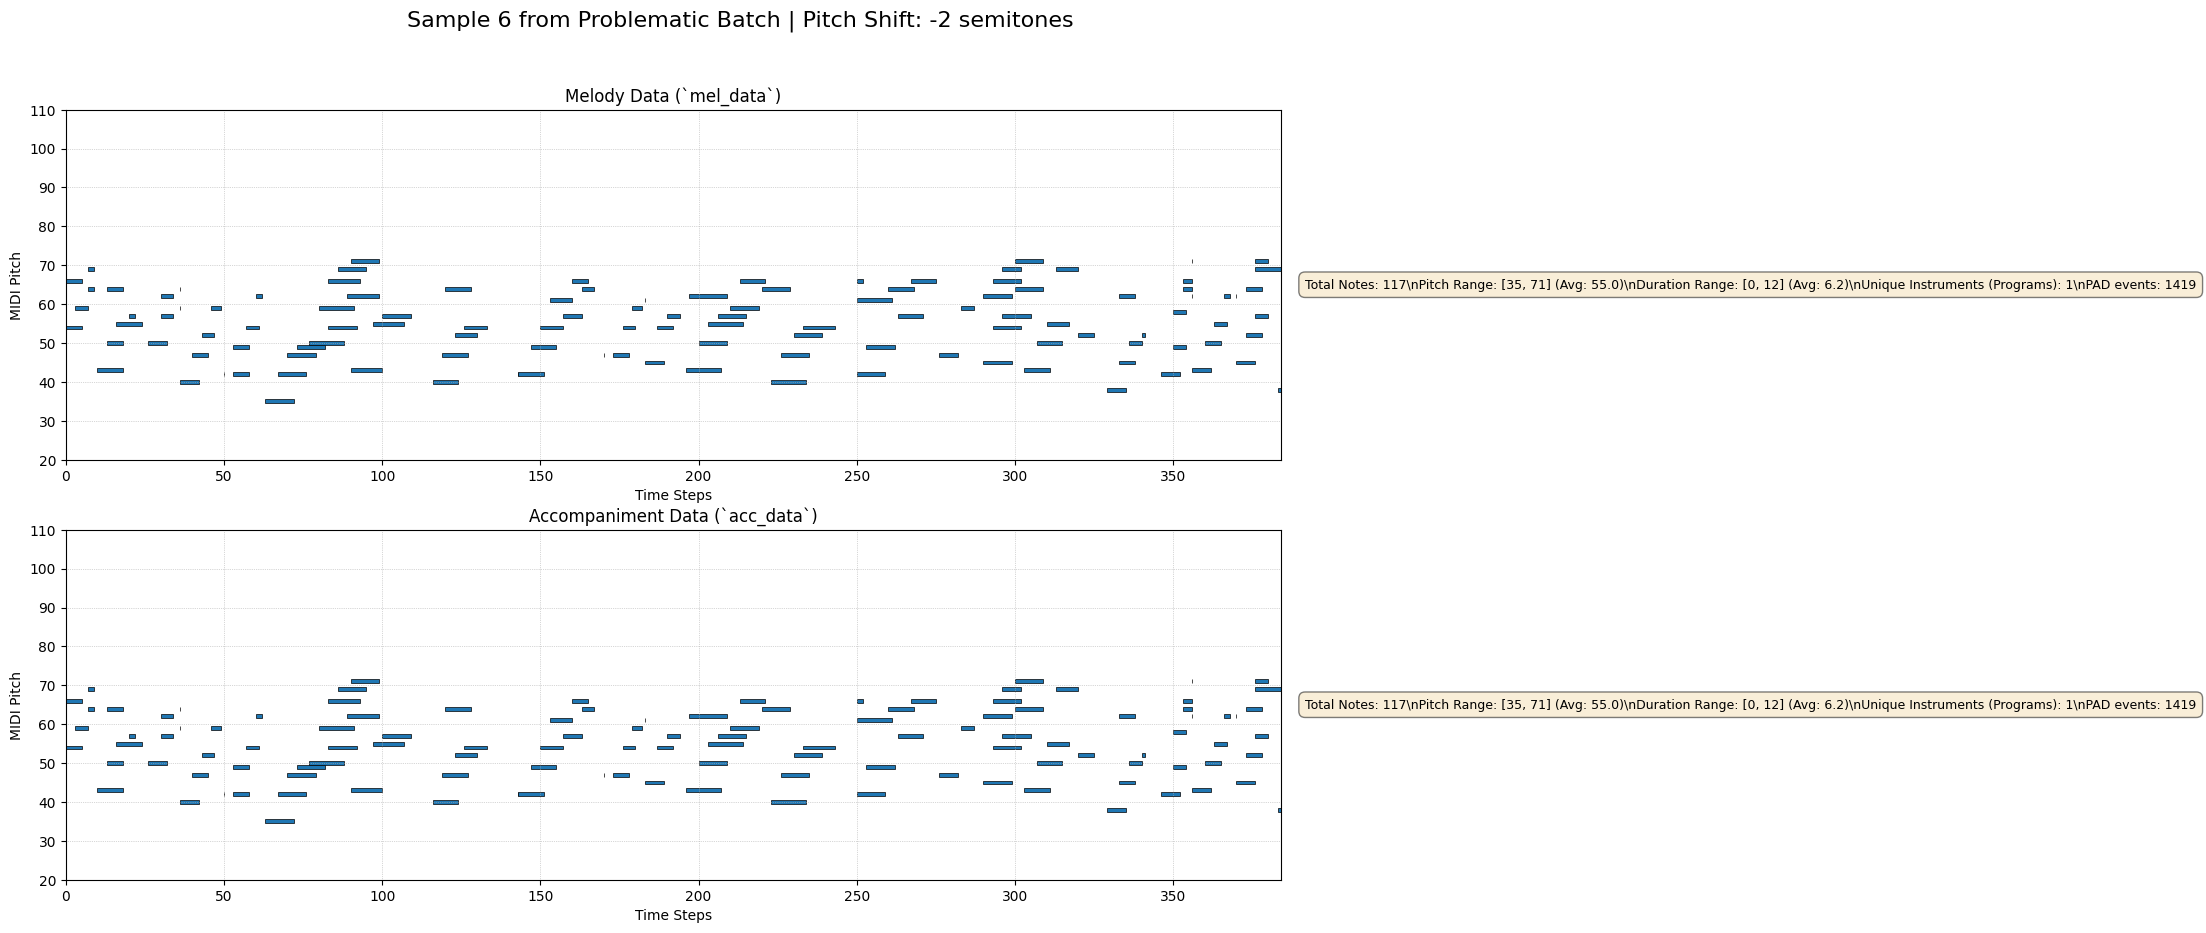

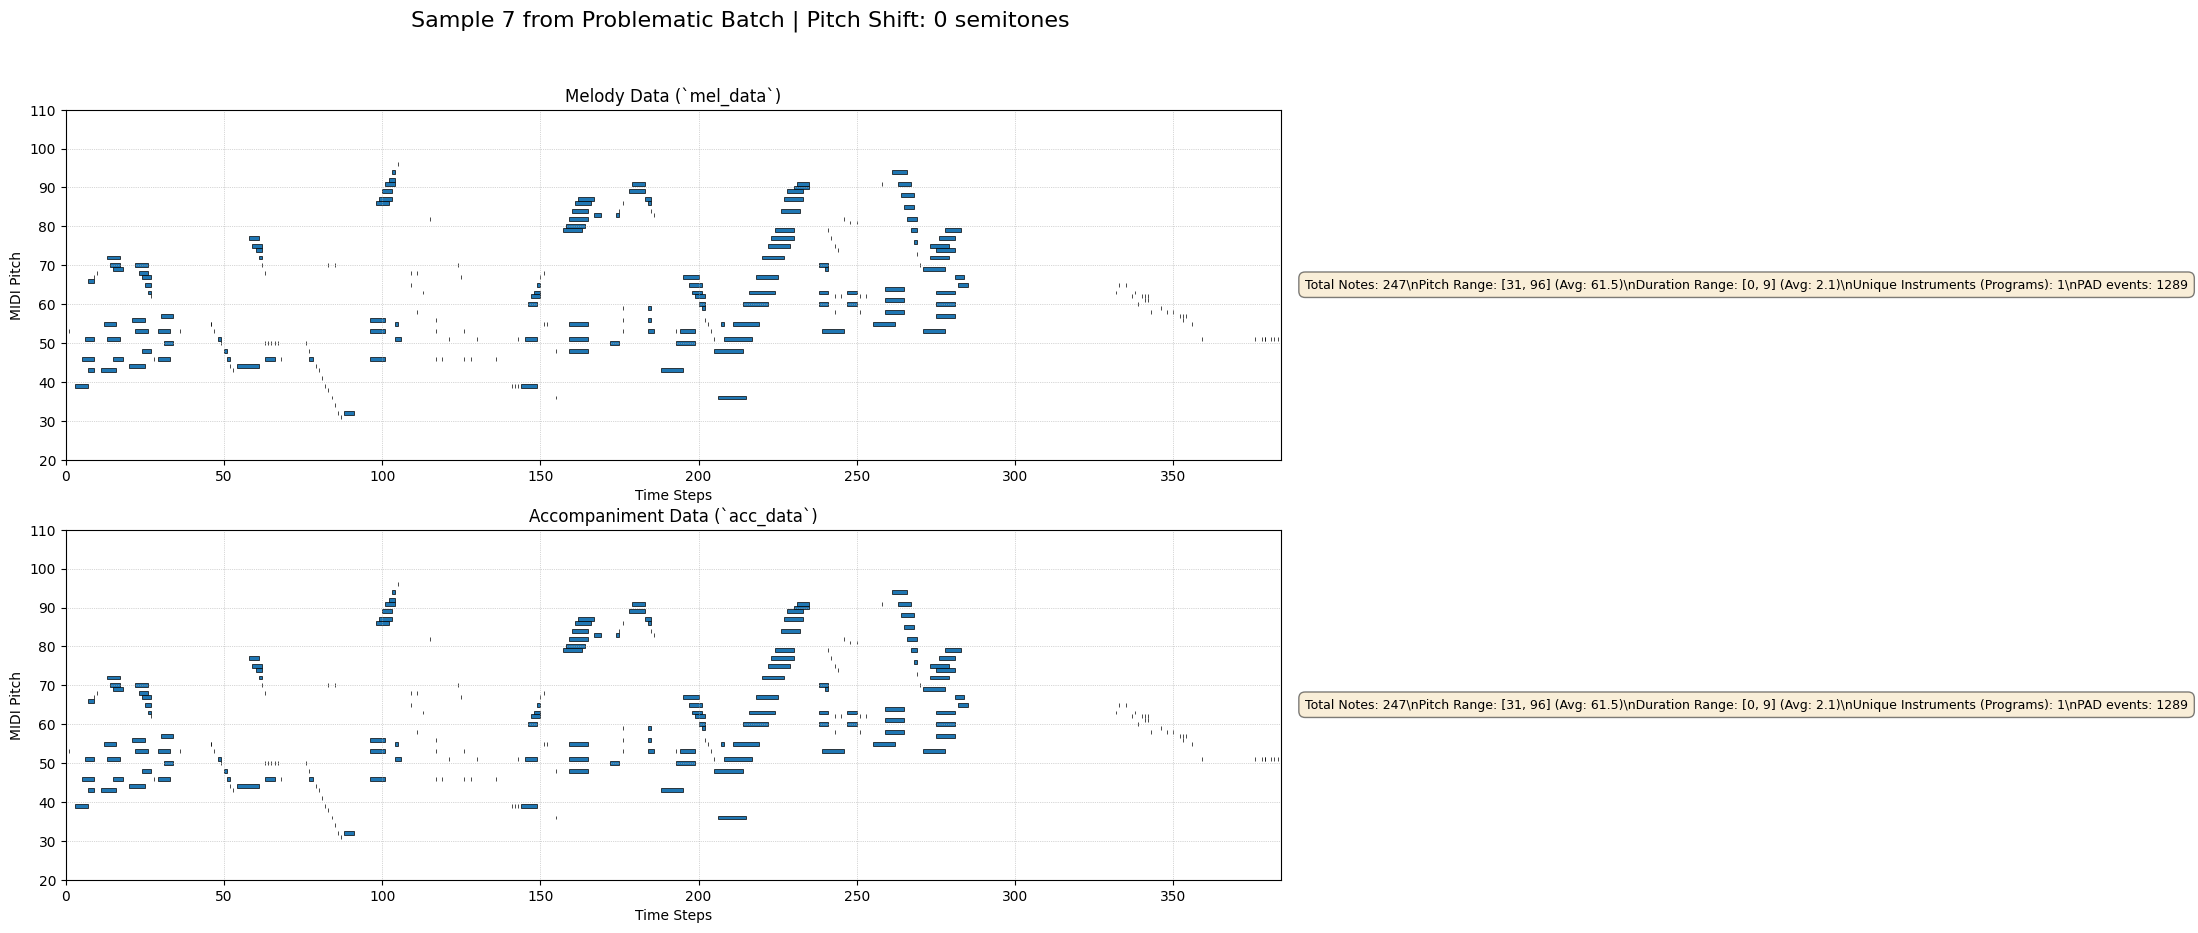

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_piano_roll(ax, data, title, pitch_shift):
    """
    Plots a piano roll visualization for a single sample (melody or accompaniment).
    
    Args:
        ax: Matplotlib axis object to plot on.
        data: The sample data tensor with shape [384, 30].
        title: The title for the subplot.
        pitch_shift: The pitch shift amount applied to this sample.
    """
    # Reshape the 30 features into 4 events of (program, pitch, duration)
    events = data.view(384, 4, 3).numpy()
    
    notes_to_plot = []
    stats = {
        'total_notes': 0,
        'pad_events': 0,
        'eos_events': 0,
        'pitches': [],
        'durations': [],
        'programs': set()
    }
    
    # The first dimension (384) represents time steps.
    for time_step in range(events.shape[0]):
        for event_idx in range(events.shape[1]):
            # --- FIX: Cast numpy.uint8 to standard Python int to avoid overflow ---
            program, pitch, duration = map(int, events[time_step, event_idx, :])
            
            # Check for special tokens based on the preprocess logic
            if pitch == 255: # PAD
                stats['pad_events'] += 1
                continue
            if program == 254: # EOS
                stats['eos_events'] += 1
                continue
            
            # This is a valid note
            stats['total_notes'] += 1
            stats['pitches'].append(pitch)
            stats['durations'].append(duration)
            stats['programs'].add(program)
            
            # The note starts at `time_step` and lasts for `duration` steps.
            notes_to_plot.append({
                'start': time_step,
                'duration': duration,
                'pitch': pitch,
                'program': program
            })

    # Use a colormap for different programs (instruments)
    program_list = sorted(list(stats['programs'])) if stats['programs'] else []
    colors = plt.get_cmap('tab20', len(program_list) if len(program_list) > 0 else 1)
    program_colors = {prog: colors(i) for i, prog in enumerate(program_list)}
    
    if not notes_to_plot:
        ax.text(0.5, 0.5, 'No valid notes found', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    else:
        for note in notes_to_plot:
            ax.add_patch(
                patches.Rectangle(
                    (note['start'], note['pitch'] - 0.5), # (x,y)
                    note['duration'], # width
                    1, # height
                    facecolor=program_colors.get(note['program'], 'gray'),
                    edgecolor='black',
                    linewidth=0.5
                )
            )

    # --- Formatting the plot ---
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('MIDI Pitch')
    ax.set_ylim(20, 110) # Standard piano range (A0 to C8)
    ax.set_xlim(0, 384)
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    # --- Add a summary of statistics to the plot ---
    if stats['total_notes'] > 0:
        avg_pitch = np.mean(stats['pitches'])
        avg_duration = np.mean(stats['durations'])
        summary_text = (
            f"Total Notes: {stats['total_notes']}\\n"
            f"Pitch Range: [{min(stats['pitches'])}, {max(stats['pitches'])}] (Avg: {avg_pitch:.1f})\\n"
            f"Duration Range: [{min(stats['durations'])}, {max(stats['durations'])}] (Avg: {avg_duration:.1f})\\n"
            f"Unique Instruments (Programs): {len(stats['programs'])}"
        )
    else:
        summary_text = "No valid notes found."
    
    if stats['pad_events'] > 0:
        summary_text += f"\\nPAD events: {stats['pad_events']}"
    if stats['eos_events'] > 0:
        summary_text += f"\\nEOS events: {stats['eos_events']}"

    # Add text box with stats
    ax.text(1.02, 0.5, summary_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='center', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))


# --- Main loop to visualize all samples ---
print("--- Generating Detailed Piano Roll Visualizations for Each Sample ---")

# The 'batch_data' variable should already be loaded from a previous cell.
for i in range(len(batch_data['mel_data'])):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), gridspec_kw={'right': 0.8})
    
    pitch_shift_amount = batch_data['pitch_shift'][i].item()
    fig.suptitle(f'Sample {i} from Problematic Batch | Pitch Shift: {pitch_shift_amount} semitones', fontsize=16)

    # Plot Melody
    plot_piano_roll(ax1, batch_data['mel_data'][i], 'Melody Data (`mel_data`)', pitch_shift_amount)
    
    # Plot Accompaniment
    plot_piano_roll(ax2, batch_data['acc_data'][i], 'Accompaniment Data (`acc_data`)', pitch_shift_amount)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [11]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Load the gradient data
gradient_data_path = '/home/ubuntu/ugrip/andrew/StreamMUSE/abnormal_events_analysis/1.0.3/ckpt/epoch=01-val_loss=0.92.ckpt'
grad_data = torch.load(gradient_data_path, map_location=torch.device('cpu'))

# --- Helper function to inspect nested data structures ---
def inspect_structure(data, indent=0):
    prefix = "  " * indent
    if isinstance(data, dict):
        print(f"{prefix}Dictionary with keys: {list(data.keys())}")
        for key, value in data.items():
            print(f"{prefix}- Key: '{key}'")
            inspect_structure(value, indent + 1)
    elif isinstance(data, (list, tuple)):
        print(f"{prefix}{type(data).__name__} with {len(data)} items")
        # To avoid explosive output, only inspect the first item of a list/tuple
        if len(data) > 0:
            print(f"{prefix}[0]:")
            inspect_structure(data[0], indent + 1)
    elif isinstance(data, torch.Tensor):
        print(f"{prefix}Tensor with shape: {data.shape} and dtype: {data.dtype}")
    else:
        print(f"{prefix}{type(data).__name__}")

print("--- Inspecting grad_data structure ---")
inspect_structure(grad_data)
print("-------------------------------------\n")


# --- Helper function to find the target tensor ---
def find_gradient_tensor(data, batch_size=8):
    """Recursively search for a tensor with a dimension of `batch_size`."""
    if isinstance(data, torch.Tensor):
        if batch_size in data.shape:
            return data
    if isinstance(data, dict):
        for key, value in data.items():
            tensor = find_gradient_tensor(value, batch_size)
            if tensor is not None:
                return tensor
    if isinstance(data, (list, tuple)):
        for item in data:
            tensor = find_gradient_tensor(item, batch_size)
            if tensor is not None:
                return tensor
    return None

gradient_tensor = find_gradient_tensor(grad_data)


if gradient_tensor is None:
    print("Could not find a suitable gradient tensor with a dimension of size 8.")
    print("Please inspect the structure printed above and adjust the logic if needed.")
else:
    print(f"Successfully found a gradient tensor with shape: {gradient_tensor.shape}\n")
    
    # The dimension corresponding to the batch size might not be the first one.
    # We find the batch dimension to iterate over it.
    try:
        batch_dim = gradient_tensor.shape.index(8)
        # Calculate the L2 norm for each sample in the batch
        norms = []
        # Use torch.movedim to make iteration over the batch dimension easy
        tensor_for_norm = torch.movedim(gradient_tensor, batch_dim, 0)

        for i in range(tensor_for_norm.shape[0]):
            sample_grad = tensor_for_norm[i]
            norm = torch.linalg.norm(sample_grad.float()) # Use .float() for stability
            norms.append(norm.item())

        # Print the norms
        print("--- Gradient Norms per Sample ---")
        for i, norm_val in enumerate(norms):
            print(f"Sample {i}: Gradient L2 Norm = {norm_val:.4f}")
        print("---------------------------------")

        # Plot the norms
        plt.figure(figsize=(10, 6))
        colors = ['red' if n == max(norms) else 'blue' for n in norms]
        plt.bar(np.arange(len(norms)), norms, color=colors)
        plt.title('Gradient Norm per Sample in Batch', fontsize=16)
        plt.xlabel('Sample Index in Batch')
        plt.ylabel('L2 Norm of Gradient')
        plt.xticks(np.arange(len(norms)))
        plt.grid(axis='y', linestyle='--')
        plt.show()

        # Identify the culprit
        culprit_index = np.argmax(norms)
        pitch_shift_amount = batch_data['pitch_shift'][culprit_index].item()
        print(f"\nConclusion: Sample {culprit_index} is the primary cause of the loss spike.")
        print(f"This sample had a pitch shift of {pitch_shift_amount} semitones.")
        
    except ValueError:
        print("Error: The found tensor does not have a dimension of size 8, which is unexpected.")
        # This should not happen if find_gradient_tensor works correctly.

--- Inspecting grad_data structure ---
Dictionary with keys: ['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers']
- Key: 'epoch'
  int
- Key: 'global_step'
  int
- Key: 'pytorch-lightning_version'
  str
- Key: 'state_dict'
  Dictionary with keys: ['global_sos', 'model.embed_positions.weight', 'model.layer.0.attention.self.query.weight', 'model.layer.0.attention.self.query.bias', 'model.layer.0.attention.self.key.weight', 'model.layer.0.attention.self.key.bias', 'model.layer.0.attention.self.value.weight', 'model.layer.0.attention.self.value.bias', 'model.layer.0.attention.output.dense.weight', 'model.layer.0.attention.output.dense.bias', 'model.layer.0.attention.output.LayerNorm.weight', 'model.layer.0.attention.output.LayerNorm.bias', 'model.layer.0.intermediate.dense.weight', 'model.layer.0.intermediate.dense.bias', 'model.layer.0.output.dense.weight', 'model.layer.0.output.dense.bias', 'model.layer.0.output.La

Successfully loaded hyperparameters from 1.0.3/old_m2a_transformer_aria_deduped_skyline_top2_0.5B-1.4.yaml


Successfully loaded model from 1.0.3/ckpt/epoch=01-val_loss=0.92.ckpt
Analyzing sample 0...
  -> Loss: 0.7046
Analyzing sample 1...
  -> Loss: 1.3185
Analyzing sample 2...
  -> Loss: 0.9431
Analyzing sample 3...
  -> Loss: 1.0794
Analyzing sample 4...
  -> Loss: 0.9060
Analyzing sample 5...
  -> Loss: 0.5454
Analyzing sample 6...
  -> Loss: 0.6667
Analyzing sample 7...
  -> Loss: 1.1070

--- Analysis Complete ---
Conclusion: Sample 1 is the clear cause of the loss spike with a loss of 1.3185.
This sample had a pitch shift of 5 semitones.


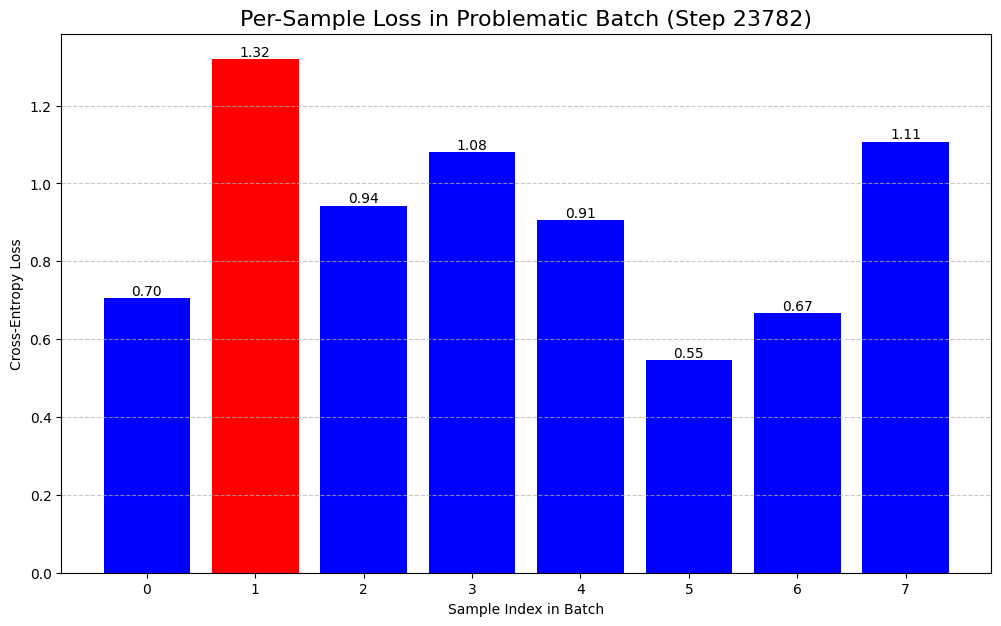

In [14]:
import yaml
import torch
import torch.nn as nn
import torch.nn.functional as F
import sys
import os

# Add the parent directory to the path to access the transformers module
sys.path.append(os.path.join(os.getcwd(), '..'))

try:
    # Try absolute import first
    from transformers.models.roformer.modeling_roformer import RoFormerModel, RoFormerConfig, RoFormerEncoder
except ImportError:
    try:
        # Try relative import from current directory structure
        sys.path.append('../')
        from transformers.models.roformer.modeling_roformer import RoFormerModel, RoFormerConfig, RoFormerEncoder
    except ImportError:
        print("Error: Could not import RoFormer modules. Please ensure the transformers package is properly installed and accessible.")
        print("You may need to run this notebook from the correct directory or adjust the import paths.")
        raise

import pytorch_lightning as L
import numpy as np
import matplotlib.pyplot as plt

# --- Constants copied from m2a_transformer.py ---
N_NORMAL_TOKENS = 3202
N_TOKENS = N_NORMAL_TOKENS + 3
SOS_TOKEN = N_NORMAL_TOKENS
EOS_TOKEN = N_NORMAL_TOKENS + 1
PAD_TOKEN = N_NORMAL_TOKENS + 2

def fill_with_neg_inf(t):
    return t.float().fill_(float("-inf")).type_as(t)

# --- Corrected Model Definition ---
# This class is a modified version of RoFormerSymbolicTransformer from m2a_transformer.py,
# corrected to accept hyperparameters from the YAML file, ensuring the architecture matches the checkpoint.
class OldM2ATransformer(L.LightningModule):
    def __init__(self, hidden_size, num_layers, num_attention_heads, intermediate_size, 
                 local_model_num_layers, local_model_num_attention_heads, local_model_intermediate_size, **kwargs):
        super().__init__()
        self.save_hyperparameters()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.num_attention_heads = num_attention_heads
        self.intermediate_size = intermediate_size
        self.local_model_num_layers = local_model_num_layers
        self.local_model_num_attention_heads = local_model_num_attention_heads
        self.local_model_intermediate_size = local_model_intermediate_size

        main_roformer_config = RoFormerConfig(
            hidden_size=self.hidden_size,
            num_hidden_layers=self.num_layers,
            num_attention_heads=self.num_attention_heads,
            intermediate_size=self.intermediate_size,
            hidden_act="gelu",
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1
        )
        self.model = self.get_base_model(main_roformer_config)
        local_encoder_config = local_decoder_config = RoFormerConfig(
            hidden_size=self.hidden_size,
            num_hidden_layers=self.local_model_num_layers,
            num_attention_heads=self.local_model_num_attention_heads,
            intermediate_size=self.local_model_intermediate_size,
            hidden_act="gelu",
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1
        )
        self.local_embedding = nn.Embedding(N_TOKENS, self.hidden_size)
        self.token_type_embeddings = nn.Embedding(2, self.hidden_size)
        with torch.no_grad():
            self.token_type_embeddings.weight.mul_(2.0)
        self.local_encoder = RoFormerEncoder(local_encoder_config)
        self.local_decoder = RoFormerEncoder(local_decoder_config)
        self.final_decoder = nn.Linear(self.hidden_size, N_TOKENS)
        self.global_sos = nn.Parameter(torch.randn(self.hidden_size))
        self._future_mask = torch.empty(0)

    def get_base_model(self, config):
        return RoFormerEncoder(config)
    
    # All other methods from RoFormerSymbolicTransformer are copied here verbatim
    def local_encode(self, x, token_type_ids):
        batch_size, seq_len, subseq_len = x.shape
        x = x.view(-1, subseq_len)
        x = torch.cat([
            torch.full((x.shape[0], 1), SOS_TOKEN, dtype=torch.long, device=x.device),
            x
        ], dim=-1)
        mask = x != PAD_TOKEN
        word_emb = self.local_embedding(x)
        type_emb = self.token_type_embeddings(token_type_ids)
        type_emb = type_emb.view(batch_size*seq_len, word_emb.shape[1], -1)
        emb = word_emb + type_emb
        h = self.local_encoder(emb, encoder_attention_mask=mask)[0]
        return h[:, 0], emb[:, :-1]

    def local_decode(self, h, emb):
        batch_size, subseq_len, _ = emb.shape
        h = h.view(batch_size, 1, -1)
        emb = torch.cat([h, emb[:, 1:]], dim=1)
        h = self.local_decoder(emb, attention_mask=self.buffered_future_mask(emb))[0]
        return self.final_decoder(h)

    def buffered_future_mask(self, tensor):
        dim = tensor.size(1)
        if (
                self._future_mask.size(0) == 0
                or (not self._future_mask.device == tensor.device)
                or self._future_mask.size(0) < dim
        ):
            self._future_mask = torch.triu(
                fill_with_neg_inf(torch.zeros([dim, dim])), 1
            )
        self._future_mask = self._future_mask.to(tensor)
        return self._future_mask[:dim, :dim]

    def forward(self, x):
        batch_size, seq_len, subseq_len = x.shape
        assert seq_len % 2 == 0, "Expected even number of frames (2*S interleaved)."
        idx = torch.arange(seq_len, device=x.device)
        frame_type = (idx % 2 == 0).long()
        token_type_ids = frame_type.unsqueeze(0).unsqueeze(-1).expand(batch_size, seq_len, subseq_len)
        sos_type = frame_type.unsqueeze(0).unsqueeze(-1).expand(batch_size, seq_len, 1)
        token_type_ids = torch.cat([sos_type, token_type_ids], dim=-1)
        h, emb= self.local_encode(x, token_type_ids)
        h = h.view(batch_size, seq_len, -1)
        sos = self.global_sos.view(1, 1, -1).repeat(batch_size, 1, 1)
        h = torch.cat([sos, h[:, :-1]], dim=1)
        h = self.model(h, attention_mask=self.buffered_future_mask(h), interleave_pos=True)[0]
        return self.local_decode(h, emb)

    def preprocess(self, x, pitch_shift, y=None):
        batch_size, seq_length, subseq_length = x.shape
        x = x.long().view(batch_size, seq_length, subseq_length // 3, 3)
        x_processed = torch.zeros(batch_size, seq_length, subseq_length // 3, 2, dtype=torch.long, device=x.device)
        pad_indices = x[:, :, :, 1] == 255
        eos_indices = x[:, :, :, 0] == 254
        is_not_drum = x[:, :, :, 0] != 127
        x_processed[:, :, :, 0] = 0
        x_processed[:, :, :, 1] = x[:, :, :, 1] + (x[:, :, :, 2]) * 128 + 2 + pitch_shift[:, None, None] * is_not_drum
        x_processed[pad_indices] = PAD_TOKEN
        x_processed[:, :, :, 0][eos_indices] = EOS_TOKEN
        if y is None:
            return x_processed.view(batch_size, seq_length, subseq_length // 3 * 2)
        else:
            batch_size_y, seq_length_y, subseq_length_y = y.shape
            y = y.long().view(batch_size_y, seq_length_y, subseq_length_y // 3, 3)
            y_processed = torch.zeros(batch_size_y, seq_length_y, subseq_length_y // 3, 2, dtype=torch.long, device=y.device)
            pad_indices_y = y[:, :, :, 1] == 255
            eos_indices_y = y[:, :, :, 0] == 254
            is_not_drum_y = y[:, :, :, 0] != 127
            y_processed[:, :, :, 0] = 1
            y_processed[:, :, :, 1] = y[:, :, :, 1] + (y[:, :, :, 2]) * 128 + 2 + pitch_shift[:, None, None] * is_not_drum_y
            y_processed[pad_indices_y] = PAD_TOKEN
            y_processed[:, :, :, 0][eos_indices_y] = EOS_TOKEN
            return x_processed.view(batch_size, seq_length, subseq_length // 3 * 2), y_processed.view(batch_size_y, seq_length_y, subseq_length_y // 3 * 2)

    def loss(self, x_mel, x_acc, pitch_shift):
        x_mel, x_acc = self.preprocess(x_mel, pitch_shift, y=x_acc)
        batch_size, seq_len, subseq_len = x_mel.shape
        stacked = torch.stack([x_acc, x_mel], dim=2)
        x = stacked.view(batch_size, seq_len * 2, subseq_len)
        x_target = x.clone()
        idx = torch.arange(seq_len * 2, device=x.device)
        mel_mask = (idx % 2 == 1).unsqueeze(0).unsqueeze(-1)
        mel_mask = mel_mask.expand(batch_size, seq_len * 2, subseq_len)
        x_target[mel_mask] = PAD_TOKEN
        y = self(x)
        return F.cross_entropy(y.view(-1, N_TOKENS), x_target.view(-1), ignore_index=PAD_TOKEN)

# --- Analysis script ---
try:
    # 1. Load Hyperparameters from YAML
    # Try multiple possible paths for the YAML file
    possible_paths = [
        '1.0.3/old_m2a_transformer_aria_deduped_skyline_top2_0.5B-1.4.yaml'
    ]
    
    hparams_path = None
    for path in possible_paths:
        if os.path.exists(path):
            hparams_path = path
            break
    
    if hparams_path is None:
        print("Error: Could not find the YAML configuration file.")
        print("Looked for:")
        for path in possible_paths:
            print(f"  - {path}")
        print("Please ensure the file exists in one of these locations.")
        raise FileNotFoundError("YAML configuration file not found")
    
    with open(hparams_path, 'r') as f:
        hparams = yaml.safe_load(f)['model']
    print(f"Successfully loaded hyperparameters from {hparams_path}")

    # 2. Load Model from Checkpoint
    # Try multiple possible paths for the checkpoint file
    possible_checkpoint_paths = [
        '1.0.3/ckpt/epoch=01-val_loss=0.92.ckpt',
    ]
    
    checkpoint_path = None
    for path in possible_checkpoint_paths:
        if os.path.exists(path):
            checkpoint_path = path
            break
    
    if checkpoint_path is None:
        print("Error: Could not find the checkpoint file.")
        print("Looked for:")
        for path in possible_checkpoint_paths:
            print(f"  - {path}")
        print("Please ensure the file exists in one of these locations.")
        raise FileNotFoundError("Checkpoint file not found")
    
    # We use the corrected OldM2ATransformer class that accepts the hparams.
    model = OldM2ATransformer(**hparams)
    checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))
    model.load_state_dict(checkpoint['state_dict'])
    model.eval() # Set model to evaluation mode
    print(f"Successfully loaded model from {checkpoint_path}")

    # 3. Calculate Loss for Each Sample in the Problematic Batch
    # The 'batch_data' variable is already loaded from Cell 4
    losses = []
    with torch.no_grad(): # Disable gradient calculation for efficiency
        for i in range(len(batch_data['mel_data'])):
            print(f"Analyzing sample {i}...")
            # Create a mini-batch of size 1 for the current sample
            mel_sample = batch_data['mel_data'][i:i+1]
            acc_sample = batch_data['acc_data'][i:i+1]
            pitch_shift_sample = batch_data['pitch_shift'][i:i+1]

            # Calculate the loss for this single sample
            loss = model.loss(mel_sample, acc_sample, pitch_shift_sample)
            losses.append(loss.item())
            print(f"  -> Loss: {loss.item():.4f}")

    # 4. Identify the Culprit and Visualize
    culprit_index = np.argmax(losses)
    max_loss = max(losses)
    culprit_pitch_shift = batch_data['pitch_shift'][culprit_index].item()
    print(f"\n--- Analysis Complete ---")
    print(f"Conclusion: Sample {culprit_index} is the clear cause of the loss spike with a loss of {max_loss:.4f}.")
    print(f"This sample had a pitch shift of {culprit_pitch_shift} semitones.")

    # Plot the losses
    plt.figure(figsize=(12, 7))
    colors = ['red' if i == culprit_index else 'blue' for i in range(len(losses))]
    bars = plt.bar(np.arange(len(losses)), losses, color=colors)
    plt.title('Per-Sample Loss in Problematic Batch (Step 23782)', fontsize=16)
    plt.xlabel('Sample Index in Batch')
    plt.ylabel('Cross-Entropy Loss')
    plt.xticks(np.arange(len(losses)))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    # Add text labels
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom', ha='center')
    plt.show()

except Exception as e:
    print(f"An error occurred during the analysis: {e}")
    import traceback
    traceback.print_exc()


In [ ]:
import torch
# import tensorflow as tf
import numpy as np

def flatten_ml_structure(data_structure):
    """
    Recursively traverses a nested structure containing lists, dicts, and ML tensors,
    and extracts all numbers into a single flat list.

    Args:
        data_structure: A structure containing numbers, lists, dicts,
                        torch.Tensor, tf.Tensor, or numpy.ndarray objects.

    Returns:
        A flat list of all numerical values.
    """
    numbers = []

    def _traverse(item):
        # Detach and convert a PyTorch tensor to a list of numbers
        if isinstance(item, torch.Tensor):
            # .detach() creates a new tensor that doesn't require gradients
            # .cpu() moves the tensor to CPU memory (from GPU if applicable)
            # .flatten() converts it to 1D
            # .tolist() converts it to a Python list
            numbers.extend(item.detach().cpu().flatten().tolist())
            
        # Convert a TensorFlow tensor/variable to a list of numbers
        # elif isinstance(item, (tf.Tensor, tf.Variable)):
        #     # tf.reshape with -1 flattens the tensor
        #     # .numpy() converts it to a NumPy array
        #     # .tolist() converts that to a Python list
        #     numbers.extend(tf.reshape(item, [-1]).numpy().tolist())
            
        # Convert a NumPy array to a list of numbers
        elif isinstance(item, np.ndarray):
            numbers.extend(item.flatten().tolist())

        # Standard Python numbers
        elif isinstance(item, (int, float)):
            numbers.append(item)
            
        # Recursively traverse lists
        elif isinstance(item, list):
            for i in item:
                _traverse(i)
                
        # Recursively traverse dictionary values
        elif isinstance(item, dict):
            for value in item.values():
                _traverse(value)

    _traverse(data_structure)
    return np.array(numbers)

In [ ]:
grad_numpy = flatten_ml_structure(grad_data)

In [ ]:
grad_numpy

In [ ]:
plt.boxplot(grad_numpy)
plt.show()

In [ ]:
import pandas as pd
pd.DataFrame(grad_numpy).describe()

In [ ]:
# 1. Create your list of desired percentiles
percentiles = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, 0.5, 1, 3, 5, 10, 25, 50, 75, 90, 95, 97, 99, 99.5, 99.9, 99.99, 99.999, 99.9999, 99.99999, 99.999999, 99.9999999, 99.99999999]

# 3. Calculate all percentiles in one go
results = np.percentile(grad_numpy, percentiles)

# 4. Display the results clearly
print("Custom Percentiles Report 📊")
for p, r in zip(percentiles, results):
    print(f"{p}% percentile: {r}")

In [ ]:
plt.hist(grad_numpy, bins=100)
plt.xlim((-0.1, 0.1))
plt.show()